# Rapport intermédiaire - Carnet d'ordres

#### Lizhan Hong, Tom Zhang

# Code externe au notebook

Ce notebook utilise des fonctions codées dans d'autres fichiers. Pour le rendu intermédiaire, nous avons importé toutes les fonctions dans les cellules suivantes.

Ci-dessous, les fonctions utilsées depuis le fichier hitting_times.py :

In [ ]:
import numpy as np
from dataclasses import dataclass
from typing import Optional

@dataclass
class HittingTimeResult:
    """Résultat d'une simulation de deux files jusqu'à la première atteinte de 0."""
    hitting_time: float          # temps où la première file atteint 0
    which_hit: int               # +1 si Q_1 atteint 0 en premier, -1 pour Q_{-1}
    q1_path: np.ndarray          # trajectoire de Q_1
    q_neg1_path: np.ndarray      # trajectoire de Q_{-1}
    times: np.ndarray            # instants enregistrés
    q1_final: int                # valeur finale de Q_1
    q_neg1_final: int            # valeur finale de Q_{-1}

def simulate_until_hit_zero(
    q1_init: int = 10,
    q_neg1_init: int = 10,
    lambda_plus: float = 1.2,
    lambda_minus: float = 1.5,
    rng: Optional[np.random.Generator] = None,
    max_events: int = 1_000_000,
    record_path: bool = True,
) -> HittingTimeResult:
    """
    Simule deux files birth-death indépendantes jusqu'à ce que l'une atteigne 0.

    Pour chaque file :
        +1 au taux λ⁺, ce qui représente un ajout dans la file ;
        -1 au taux λ⁻, ce qui représente un retrait.

    Les deux files sont indépendantes. Le critère d'arrêt est
    min(Q_1, Q_{-1}) = 0.
    """
    if rng is None:
        rng = np.random.default_rng()

    q1 = q1_init
    q_neg1 = q_neg1_init
    t = 0.0

    # Taux total du système : chaque file a le taux λ⁺ + λ⁻.
    rate_per_queue = lambda_plus + lambda_minus
    total_rate = 2 * rate_per_queue

    # Probabilités des quatre types d'événements :
    #   ajout dans Q_1, retrait dans Q_1,
    #   ajout dans Q_{-1}, retrait dans Q_{-1}.
    p_q1_add = lambda_plus / total_rate
    p_q1_rem = lambda_minus / total_rate
    p_qn1_add = lambda_plus / total_rate
    # p_qn1_rem = lambda_minus / total_rate, implicite en fait.

    cumprobs = np.array([p_q1_add, p_q1_add + p_q1_rem,
                         p_q1_add + p_q1_rem + p_qn1_add])

    if record_path:
        times_list = [0.0]
        q1_list = [q1]
        qn1_list = [q_neg1]

    for _ in range(max_events):
        # Temps d'attente jusqu'au prochain événement.
        dt = rng.exponential(1.0 / total_rate)
        t += dt

        # Choix du type d'événement.
        u = rng.random()
        if u < cumprobs[0]:
            q1 += 1                  # Q_1 add
        elif u < cumprobs[1]:
            q1 = max(0, q1 - 1)     # Q_1 remove
        elif u < cumprobs[2]:
            q_neg1 += 1             # Q_{-1} add
        else:
            q_neg1 = max(0, q_neg1 - 1)  # Q_{-1} remove

        if record_path:
            times_list.append(t)
            q1_list.append(q1)
            qn1_list.append(q_neg1)

        # Condition d'arrêt : l'une des deux files est vide.
        if q1 <= 0 or q_neg1 <= 0:
            which = 1 if q1 <= 0 else -1
            if record_path:
                return HittingTimeResult(
                    hitting_time=t, which_hit=which,
                    q1_path=np.array(q1_list), q_neg1_path=np.array(qn1_list),
                    times=np.array(times_list),
                    q1_final=q1, q_neg1_final=q_neg1,
                )
            else:
                return HittingTimeResult(
                    hitting_time=t, which_hit=which,
                    q1_path=np.array([]), q_neg1_path=np.array([]),
                    times=np.array([]),
                    q1_final=q1, q_neg1_final=q_neg1,
                )

    # Cas de secours si max_events est atteint avant 0.
    which = 1 if q1 <= q_neg1 else -1
    if record_path:
        return HittingTimeResult(
            t, which, np.array(q1_list), np.array(qn1_list),
            np.array(times_list), q1, q_neg1)
    return HittingTimeResult(t, which, np.array([]), np.array([]),
                             np.array([]), q1, q_neg1)

def hitting_time_pdf_brownian(t: np.ndarray, x0: float,
                              mu: float, sigma: float) -> np.ndarray:
    """
    Densité du temps d'atteinte de 0 pour X(t) = x0 + μt + σW(t).

    La formule correspond à une loi inverse gaussienne. Elle est utilisée ici
    lorsque μ < 0, cas où l'atteinte de 0 est presque sûre.
    """
    t = np.asarray(t, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        pdf = (x0 / (sigma * np.sqrt(2 * np.pi * t**3))) * \
              np.exp(-(x0 + mu * t)**2 / (2 * sigma**2 * t))
    pdf = np.where(t > 0, pdf, 0.0)
    return pdf


def hitting_time_cdf_brownian(t: np.ndarray, x0: float,
                              mu: float, sigma: float) -> np.ndarray:
    """Fonction de répartition du temps d'atteinte brownien."""
    from scipy.stats import norm
    t = np.asarray(t, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        sqrt_t = np.sqrt(t)
        term1 = norm.cdf((-x0 - mu * t) / (sigma * sqrt_t))
        term2 = np.exp(-2 * mu * x0 / sigma**2) * \
                norm.cdf((-x0 + mu * t) / (sigma * sqrt_t))
    cdf = np.where(t > 0, term1 + term2, 0.0)
    return cdf

def hitting_time_mean_brownian(x0: float, mu: float) -> float:
    """
    Espérance \\mathbb{E}[T₀] du temps d'atteinte brownien, pour μ < 0.

    \\mathbb{E}[T₀] = x0 / |μ|.
    """
    if mu >= 0:
        return np.inf  # le temps moyen est infini si le drift est non négatif
    return x0 / abs(mu)

def prob_q1_hits_first_brownian(x1: float, x2: float,
                                mu: float, sigma: float) -> float:
    """
    Approxime P(T_1 < T_2) pour deux approximations browniennes indépendantes.

    On utilise l'identité :
        P(T_1 < T_2) = ∫ f_{T_1}(t) · [1 - F_{T_2}(t)] dt.
    L'intégrale est calculée numériquement sur une grille de temps.
    """
    t_max = max(hitting_time_mean_brownian(x1, mu),
                hitting_time_mean_brownian(x2, mu)) * 5
    t_grid = np.linspace(0.001, t_max, 5000)
    dt = t_grid[1] - t_grid[0]

    f1 = hitting_time_pdf_brownian(t_grid, x1, mu, sigma)
    F2 = hitting_time_cdf_brownian(t_grid, x2, mu, sigma)

    # P(T1 < T2) = ∫ f1(t) · [1 - F2(t)] dt.
    prob = np.sum(f1 * (1 - F2) * dt)
    return float(np.clip(prob, 0, 1))

def batch_hitting_times(
    n_runs: int,
    q1_init: int = 10,
    q_neg1_init: int = 10,
    lambda_plus: float = 1.2,
    lambda_minus: float = 1.5,
    seed: int = 42,
) -> dict:
    """
    Lance n_runs simulations indépendantes et agrège les temps d'atteinte.

    Le dictionnaire retourné contient les temps simulés, la file qui atteint 0
    en premier, la moyenne empirique, l'écart-type, un IC à 95 %, et la
    fréquence empirique de l'événement {Q_1 atteint 0 en premier}.
    """
    rng = np.random.default_rng(seed)
    times = np.zeros(n_runs)
    which = np.zeros(n_runs, dtype=int)

    for k in range(n_runs):
        res = simulate_until_hit_zero(
            q1_init, q_neg1_init, lambda_plus, lambda_minus,
            rng=rng, record_path=False)
        times[k] = res.hitting_time
        which[k] = res.which_hit

    mean_T = times.mean()
    std_T = times.std()
    ci = 1.96 * std_T / np.sqrt(n_runs)

    return {
        'hitting_times': times,
        'which_hit': which,
        'mean_T': mean_T,
        'std_T': std_T,
        'ci_95': (mean_T - ci, mean_T + ci),
        'prob_q1_first': float((which == 1).mean()),
        'n_runs': n_runs,
    }

def scan_initial_conditions(
    q1_range: np.ndarray,
    q_neg1_range: np.ndarray,
    n_runs: int = 500,
    lambda_plus: float = 1.2,
    lambda_minus: float = 1.5,
    seed: int = 42,
) -> dict:
    """
    Étudie \\mathbb{E}[T_min] et P(Q_1 en premier) sur une grille de conditions initiales.

    Les matrices retournées sont indexées par Q_{-1}(0) en ligne et Q_1(0)
    en colonne.
    """
    rng = np.random.default_rng(seed)
    n1, n2 = len(q1_range), len(q_neg1_range)
    mean_T_grid = np.zeros((n2, n1))
    prob_q1_grid = np.zeros((n2, n1))

    for j, qn1 in enumerate(q_neg1_range):
        for i, q1 in enumerate(q1_range):
            times = []
            q1_firsts = 0
            for _ in range(n_runs):
                res = simulate_until_hit_zero(
                    int(q1), int(qn1), lambda_plus, lambda_minus,
                    rng=rng, record_path=False)
                times.append(res.hitting_time)
                if res.which_hit == 1:
                    q1_firsts += 1
            mean_T_grid[j, i] = np.mean(times)
            prob_q1_grid[j, i] = q1_firsts / n_runs

    return {
        'q1_range': q1_range,
        'q_neg1_range': q_neg1_range,
        'mean_T_grid': mean_T_grid,
        'prob_q1_grid': prob_q1_grid,
    }

Ci-dessous les fonctions du fichier hawkes.py :

In [ ]:
@dataclass
class HawkesQueueResult:
    """Result of a Hawkes queue simulation."""
    times: np.ndarray           # event times
    queue_path: np.ndarray      # queue size after each event
    lambda_minus_path: np.ndarray  # λ⁻(t) at each event
    event_types: np.ndarray     # +1 for add, -1 for remove
    hitting_time: float         # time when queue hits 0 (or T_max)
    hit_zero: bool

def hawkes_stationary_intensity(mu_plus: float, mu_minus: float,
                                 alpha: float, beta: float,
                                 sign_convention: str = "v4") -> float:
    """
    Stationary mean of λ⁻(t) for the Hawkes model.

    v4 corrected signs:
        λ⁻ = μ⁻ - φ*dN⁺ + φ*dN⁻
        m⁻ = (μ⁻ - (α/β)·μ⁺) / (1 - α/β)

    inverse historical signs:
        λ⁻ = μ⁻ + φ*dN⁺ - φ*dN⁻
        m⁻ = (μ⁻ + (α/β)·μ⁺) / (1 + α/β)

    Requires α/β < 1 for stationarity.
    """
    ratio = alpha / beta
    if ratio >= 1:
        raise ValueError(f"α/β = {ratio:.3f} ≥ 1: process is non-stationary!")

    return (mu_minus - ratio * mu_plus) / (1 - ratio)

def simulate_hawkes_queue(
    q_init: int = 10,
    mu_plus: float = 1.2,
    mu_minus: float = 1.5,
    alpha: float = 0.3,
    beta: float = 0.5,
    T_max: float = 1000.0,
    rng: Optional[np.random.Generator] = None,
    stop_at_zero: bool = True,
    convention: str = "v4",
) -> HawkesQueueResult:
    """
    Simulate a single queue with Hawkes removal intensity.

    λ⁺(t) = μ⁺  (constant)
    v4:
        λ⁻(t) = μ⁻ - Σ_{add} α·e^{-β(t-s)} + Σ_{rem} α·e^{-β(t-s)}
    inverse:
        λ⁻(t) = μ⁻ + Σ_{add} α·e^{-β(t-s)} - Σ_{rem} α·e^{-β(t-s)}

    Uses Ogata's thinning algorithm:
        1. Compute upper bound λ_max = λ⁺ + max(λ⁻(t), μ⁻)
        2. Draw candidate Δt ~ Exp(λ_max)
        3. Accept with probability (λ⁺ + λ⁻(t)) / λ_max
        4. If accepted, choose add vs remove proportionally

    When the queue is empty and stop_at_zero=False, removal events are
    disabled until an addition refills the queue.
    """
    if rng is None:
        rng = np.random.default_rng()
    add_jump = -alpha if convention == "v4" else alpha
    remove_jump = alpha if convention == "v4" else -alpha

    q = q_init
    t = 0.0

    times_list = [0.0]
    queue_list = [q]
    lam_minus_list = [mu_minus]
    event_types_list = [0]

    # Track the Hawkes state H(t). It decays exponentially between events
    # and jumps according to the chosen sign convention at accepted events.
    H = 0.0  # current excitation level

    while t < T_max:
        # Current λ⁻(t) = μ⁻ + H  (clamped to ≥ 0)
        lam_minus_current = max(0.0, mu_minus + H) if q > 0 else 0.0
        lam_plus_current = mu_plus

        total_rate = lam_plus_current + lam_minus_current

        if total_rate <= 0:
            break

        # Upper bound for thinning:
        # If H > 0, λ⁻ = μ⁻ + H decays → current value is max.
        # If H < 0, λ⁻ increases toward μ⁻ → μ⁻ is the max.
        lam_minus_max = mu_minus + max(H, 0) if q > 0 else 0.0
        lam_max = lam_plus_current + lam_minus_max + 0.01

        # Draw candidate inter-event time
        dt = rng.exponential(1.0 / lam_max)
        t += dt

        if t > T_max:
            break

        # Decay H to current time
        H *= np.exp(-beta * dt)

        # Accept/reject (thinning)
        lam_minus_now = max(0.0, mu_minus + H) if q > 0 else 0.0
        total_now = lam_plus_current + lam_minus_now

        if rng.random() > total_now / lam_max:
            continue  # reject (thinning)

        # Event accepted — choose type
        if rng.random() < lam_plus_current / total_now:
            # Addition event
            q += 1
            H += add_jump
            event_type = +1
        else:
            # Removal event
            q = max(0, q - 1)
            H += remove_jump
            event_type = -1

        times_list.append(t)
        queue_list.append(q)
        lam_minus_list.append(max(0.0, mu_minus + H) if q > 0 else 0.0)
        event_types_list.append(event_type)

        if stop_at_zero and q <= 0:
            return HawkesQueueResult(
                times=np.array(times_list),
                queue_path=np.array(queue_list),
                lambda_minus_path=np.array(lam_minus_list),
                event_types=np.array(event_types_list),
                hitting_time=t, hit_zero=True,
            )

    return HawkesQueueResult(
        times=np.array(times_list),
        queue_path=np.array(queue_list),
        lambda_minus_path=np.array(lam_minus_list),
        event_types=np.array(event_types_list),
        hitting_time=t, hit_zero=False,
    )


# ====================================================================== #
#  Section 1.2.4 Q2: Two coupled Hawkes queues
# ====================================================================== #


@dataclass
class CoupledHawkesResult:
    """Result of two coupled Hawkes queues simulation."""
    times: np.ndarray
    q1_path: np.ndarray        # ask queue
    q_neg1_path: np.ndarray    # bid queue
    lam_minus_1_path: np.ndarray   # λ⁻ for ask
    lam_minus_neg1_path: np.ndarray  # λ⁻ for bid
    hitting_time: float
    which_hit: int             # +1 or -1
    hit_zero: bool

def simulate_coupled_hawkes(
    q1_init: int = 10,
    q_neg1_init: int = 10,
    mu_plus: float = 1.2,
    mu_minus: float = 1.5,
    alpha: float = 0.3,
    beta: float = 0.5,
    T_max: float = 1000.0,
    rng: Optional[np.random.Generator] = None,
    stop_at_zero: bool = True,
    convention: str = "v4",
) -> CoupledHawkesResult:

    if rng is None:
        rng = np.random.default_rng()

    q1, qn1 = q1_init, q_neg1_init
    t = 0.0
    H1, Hn1 = 0.0, 0.0  # excitation states

    times_list = [0.0]
    q1_list, qn1_list = [q1], [qn1]
    lm1_list = [mu_minus]
    lmn1_list = [mu_minus]

    while t < T_max:
        # Current intensities
        lm1 = max(0.0, mu_minus + H1) if q1 > 0 else 0.0
        lmn1 = max(0.0, mu_minus + Hn1) if qn1 > 0 else 0.0

        # Upper bound: if H > 0, it will decay → current is max.
        # If H < 0, it will decay toward 0 → μ⁻ is the max.
        lm1_max = mu_minus + max(H1, 0) if q1 > 0 else 0.0
        lmn1_max = mu_minus + max(Hn1, 0) if qn1 > 0 else 0.0
        lam_max = 2 * mu_plus + lm1_max + lmn1_max + 0.01

        if lam_max <= 0:
            break

        dt = rng.exponential(1.0 / lam_max)
        t += dt
        if t > T_max:
            break

        # Decay excitations
        decay = np.exp(-beta * dt)
        H1 *= decay
        Hn1 *= decay

        # Thinning
        lm1 = max(0.0, mu_minus + H1) if q1 > 0 else 0.0
        lmn1 = max(0.0, mu_minus + Hn1) if qn1 > 0 else 0.0
        total_now = 2 * mu_plus + lm1 + lmn1

        if rng.random() > total_now / lam_max:
            continue

        # Choose which event: 4 types
        # Q1 add (μ⁺), Q1 remove (lm1), Q-1 add (μ⁺), Q-1 remove (lmn1)
        u = rng.random() * total_now
        if u < mu_plus:
            # Q1 add
            q1 += 1
            if convention == "v4":
                H1 -= alpha
                Hn1 -= alpha
            else:
                H1 += alpha
                Hn1 -= alpha
        elif u < mu_plus + lm1:
            # Q1 remove
            q1 = max(0, q1 - 1)
            if convention == "v4":
                H1 += alpha
                Hn1 += alpha
            else:
                H1 -= alpha
                Hn1 += alpha
        elif u < 2 * mu_plus + lm1:
            # Q-1 add
            qn1 += 1
            if convention == "v4":
                Hn1 -= alpha
                H1 -= alpha
            else:
                Hn1 += alpha
                H1 -= alpha
        else:
            # Q-1 remove
            qn1 = max(0, qn1 - 1)
            if convention == "v4":
                Hn1 += alpha
                H1 += alpha
            else:
                Hn1 -= alpha
                H1 += alpha

        times_list.append(t)
        q1_list.append(q1)
        qn1_list.append(qn1)
        lm1_list.append(max(0.0, mu_minus + H1) if q1 > 0 else 0.0)
        lmn1_list.append(max(0.0, mu_minus + Hn1) if qn1 > 0 else 0.0)

        if stop_at_zero and (q1 <= 0 or qn1 <= 0):
            which = 1 if q1 <= 0 else -1
            return CoupledHawkesResult(
                np.array(times_list), np.array(q1_list), np.array(qn1_list),
                np.array(lm1_list), np.array(lmn1_list),
                t, which, True)

    return CoupledHawkesResult(
        np.array(times_list), np.array(q1_list), np.array(qn1_list),
        np.array(lm1_list), np.array(lmn1_list),
        t, 0, False)

# Section 1.2.3 — Première modélisation : files de Poisson indépendantes

Ce notebook répond aux questions de la section **1.2.3** du sujet MODAL Queue Reactive.
On modélise les deux premières limites du carnet par deux files indépendantes
$Q_1$ et $Q_{-1}$. Chaque file reçoit des ajouts au taux $\lambda^\oplus$
et des retraits au taux $\lambda^\ominus$.

Les paramètres de référence sont ceux de l'énoncé :

$$
\lambda^\oplus = 1.2,\qquad \lambda^\ominus = 1.5,\qquad
Q_1(0)=Q_{-1}(0)=10.
$$

La convention utilisée dans les figures est la suivante : $Q_1$ désigne la
première limite ask et $Q_{-1}$ la première limite bid. Le temps d'arrêt est

$$
T_{\min}=\inf\{t\ge 0:\min(Q_1(t),Q_{-1}(t))=0\}.
$$


In [ ]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

from model.hitting_times import (
    simulate_until_hit_zero,
    #simulate_brownian_until_hit_zero,
    hitting_time_pdf_brownian,
    hitting_time_cdf_brownian,
    hitting_time_mean_brownian,
    prob_q1_hits_first_brownian,
    batch_hitting_times,
    scan_initial_conditions,
)
""" from model.hawkes import (
    prob_reach_zero_discrete,
    prob_reach_zero_brownian,
    compare_hitting_probabilities,
) """

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

SEED = 42
LAMBDA_PLUS = 1.2
LAMBDA_MINUS = 1.5
Q0 = 10
MU = LAMBDA_PLUS - LAMBDA_MINUS
SIGMA = np.sqrt(LAMBDA_PLUS + LAMBDA_MINUS)
print(f"Paramètres : λ⁺={LAMBDA_PLUS}, λ⁻={LAMBDA_MINUS}, μ={MU:.2f}, σ={SIGMA:.3f}, Q0={Q0}")


Paramètres : λ⁺=1.2, λ⁻=1.5, μ=-0.30, σ=1.643, Q0=10


## Question 1.2.3.0 — Simulation de base

On simule les deux files jusqu'à la première atteinte de zéro. La première
figure représente les trajectoires temporelles, et la seconde représente le
chemin dans le quadrant $(Q_1,Q_{-1})$, comme dans l'esprit de la Figure 2
du sujet.


Temps d'arrêt : 13.4866
File qui touche zéro : Q₁
Nombre d'événements : 73
État final : Q₁=0, Q₋₁=13


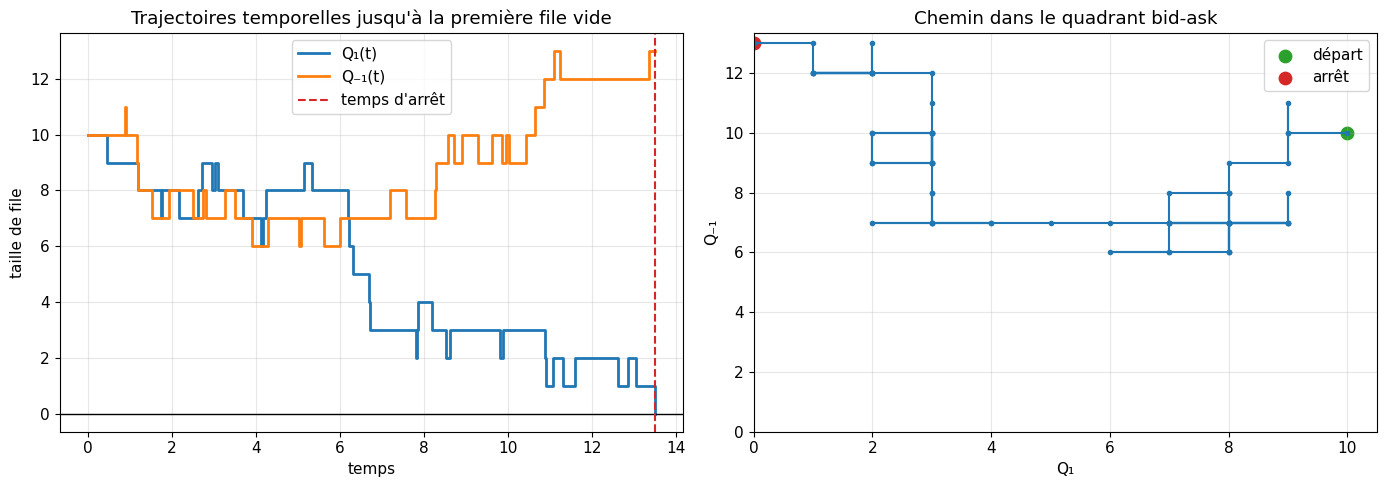

In [2]:
rng = np.random.default_rng(SEED)
res_base = simulate_until_hit_zero(
    q1_init=Q0,
    q_neg1_init=Q0,
    lambda_plus=LAMBDA_PLUS,
    lambda_minus=LAMBDA_MINUS,
    rng=rng,
    record_path=True,
)

file_touchee = "Q₁" if res_base.which_hit == 1 else "Q₋₁"
print(f"Temps d'arrêt : {res_base.hitting_time:.4f}")
print(f"File qui touche zéro : {file_touchee}")
print(f"Nombre d'événements : {len(res_base.times) - 1}")
print(f"État final : Q₁={res_base.q1_final}, Q₋₁={res_base.q_neg1_final}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].step(res_base.times, res_base.q1_path, where="post", label="Q₁(t)", linewidth=2)
axes[0].step(res_base.times, res_base.q_neg1_path, where="post", label="Q₋₁(t)", linewidth=2)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axvline(res_base.hitting_time, color="tab:red", linestyle="--", label="temps d'arrêt")
axes[0].set_xlabel("temps")
axes[0].set_ylabel("taille de file")
axes[0].set_title("Trajectoires temporelles jusqu'à la première file vide")
axes[0].legend()

axes[1].plot(res_base.q1_path, res_base.q_neg1_path, marker="o", markersize=3, linewidth=1.5)
axes[1].scatter([res_base.q1_path[0]], [res_base.q_neg1_path[0]], color="tab:green", s=80, label="départ")
axes[1].scatter([res_base.q1_path[-1]], [res_base.q_neg1_path[-1]], color="tab:red", s=80, label="arrêt")
axes[1].set_xlabel("Q₁")
axes[1].set_ylabel("Q₋₁")
axes[1].set_title("Chemin dans le quadrant bid-ask")
axes[1].set_xlim(left=0)
axes[1].set_ylim(bottom=0)
axes[1].legend()

plt.tight_layout()
plt.show()


**Interprétation.** Le chemin s'arrête dès qu'une coordonnée atteint l'axe.
Comme $\lambda^\ominus>\lambda^\oplus$, chaque file a un drift négatif
$\mu=\lambda^\oplus-\lambda^\ominus=-0.3$, ce qui rend l'atteinte de zéro
presque sûre pour chaque file prise séparément.


## Question 1.2.3.1 — Approximation brownienne

Pour une file $Q$, on écrit exactement

$$
Q(t)=Q(0)+N^\oplus(t)-N^\ominus(t),
$$

où $N^\oplus(t)\sim \mathrm{Poi}(\lambda^\oplus t)$ et
$N^\ominus(t)\sim \mathrm{Poi}(\lambda^\ominus t)$ sont indépendants.
Par additivité de l'espérance et de la variance pour des variables
indépendantes,

$$
\mathbb{E}[Q(t)]
=Q(0)+\lambda^\oplus t-\lambda^\ominus t
=Q(0)+\mu t,
$$

avec $\mu=\lambda^\oplus-\lambda^\ominus$. De même,

$$
\mathrm{Var}(Q(t))
=\mathrm{Var}(N^\oplus(t))+\mathrm{Var}(N^\ominus(t))
=\lambda^\oplus t+\lambda^\ominus t
=\sigma^2 t,
$$

où $\sigma^2=\lambda^\oplus+\lambda^\ominus$.

Le théorème central limite fonctionnel appliqué aux deux processus de Poisson
donne, à l'échelle diffusive,

$$
Q(t)\approx Q(0)+\mu t+\sigma W_t,
$$

où $W$ est un mouvement brownien standard. Cette approximation conserve le
drift et la variance instantanée du processus birth-death discret.


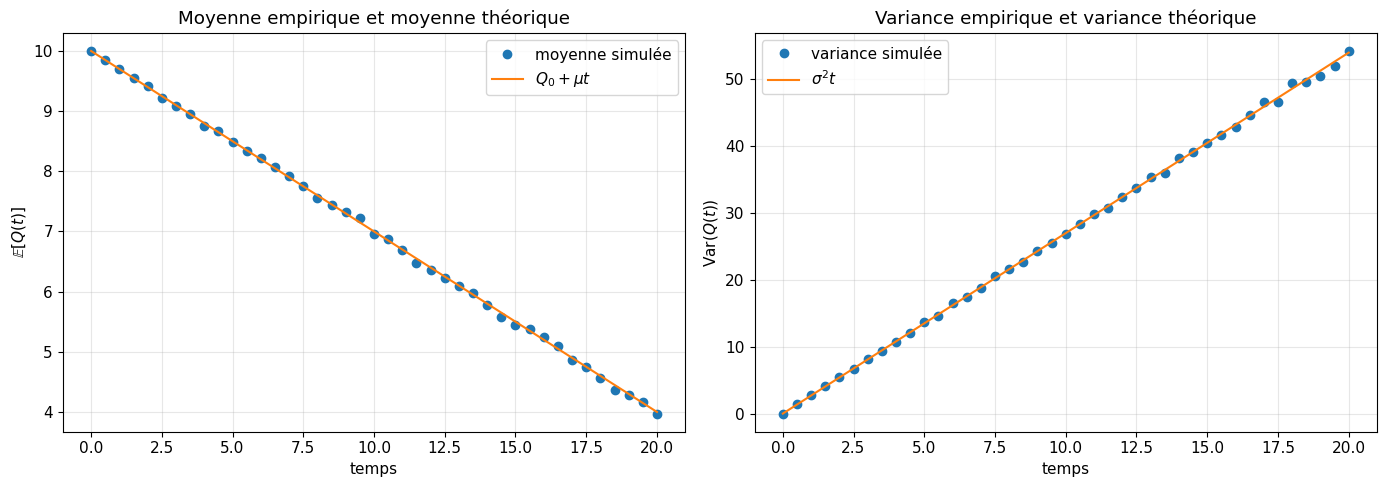

In [3]:
# Vérification numérique des moments sur la grille t = 0, 0.5, ..., 20.
rng = np.random.default_rng(SEED)
t_grid = np.arange(0, 20.5, 0.5)
n_paths_moments = 20_000

echantillons = (
    Q0
    + rng.poisson(LAMBDA_PLUS * t_grid, size=(n_paths_moments, len(t_grid)))
    - rng.poisson(LAMBDA_MINUS * t_grid, size=(n_paths_moments, len(t_grid)))
)

moy_emp = echantillons.mean(axis=0)
var_emp = echantillons.var(axis=0, ddof=1)
moy_theo = Q0 + MU * t_grid
var_theo = SIGMA**2 * t_grid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(t_grid, moy_emp, "o", label="moyenne simulée")
axes[0].plot(t_grid, moy_theo, "-", label=r"$Q_0+\mu t$")
axes[0].set_xlabel("temps")
axes[0].set_ylabel(r"$\mathbb{E}[Q(t)]$")
axes[0].set_title("Moyenne empirique et moyenne théorique")
axes[0].legend()

axes[1].plot(t_grid, var_emp, "o", label="variance simulée")
axes[1].plot(t_grid, var_theo, "-", label=r"$\sigma^2 t$")
axes[1].set_xlabel("temps")
axes[1].set_ylabel(r"$\mathrm{Var}(Q(t))$")
axes[1].set_title("Variance empirique et variance théorique")
axes[1].legend()

plt.tight_layout()
plt.show()


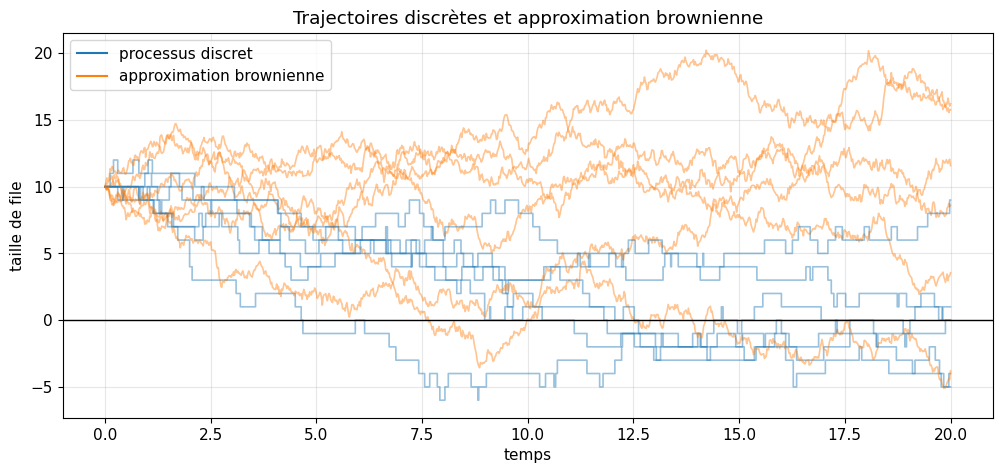

In [4]:
# Superposition de trajectoires discrètes et de trajectoires browniennes.
rng = np.random.default_rng(SEED)
T_plot = 20.0
dt_bm = 0.02
t_bm = np.arange(0, T_plot + dt_bm, dt_bm)
n_traj = 6

fig, ax = plt.subplots(figsize=(12, 5))

for k in range(n_traj):
    # Processus discret simulé par incréments indépendants sur la grille.
    add_inc = rng.poisson(LAMBDA_PLUS * dt_bm, size=len(t_bm) - 1)
    rem_inc = rng.poisson(LAMBDA_MINUS * dt_bm, size=len(t_bm) - 1)
    q_discret = Q0 + np.r_[0, np.cumsum(add_inc - rem_inc)]
    dW = rng.normal(0, np.sqrt(dt_bm), size=len(t_bm) - 1)
    W = np.r_[0.0, np.cumsum(dW)]
    q_bm = Q0 + MU * t_bm + SIGMA * W

    ax.step(t_bm, q_discret, where="post", alpha=0.45, linewidth=1.2, color="tab:blue")
    ax.plot(t_bm, q_bm, alpha=0.45, linewidth=1.2, color="tab:orange")

ax.axhline(0, color="black", linewidth=1)
ax.plot([], [], color="tab:blue", label="processus discret")
ax.plot([], [], color="tab:orange", label="approximation brownienne")
ax.set_xlabel("temps")
ax.set_ylabel("taille de file")
ax.set_title("Trajectoires discrètes et approximation brownienne")
ax.legend()
plt.show()


**Conclusion.** Les deux premiers moments coïncident avec les formules
théoriques. Les trajectoires browniennes sont continues et peuvent devenir
négatives, alors que la file discrète vit sur $\mathbb{Z}_+$ et s'arrête
au bord $0$. Cette différence devient importante pour les probabilités
d'atteinte étudiées en complément.


## Question 1.2.3.2 — Distribution des temps d'atteinte

Pour l'approximation brownienne

$$
X(t)=x_0+\mu t+\sigma W_t,\qquad \mu<0,
$$

le temps d'atteinte $T_0=\inf\{t:X(t)=0\}$ admet la densité inverse
gaussienne

$$
f(t)=\frac{x_0}{\sigma\sqrt{2\pi t^3}}
\exp\!\left(-\frac{(x_0+\mu t)^2}{2\sigma^2 t}\right),
\qquad t>0.
$$

On reproduit l'esprit de la Figure 3 : approximation brownienne, processus
de Poisson exact, puis superposition avec la densité théorique.


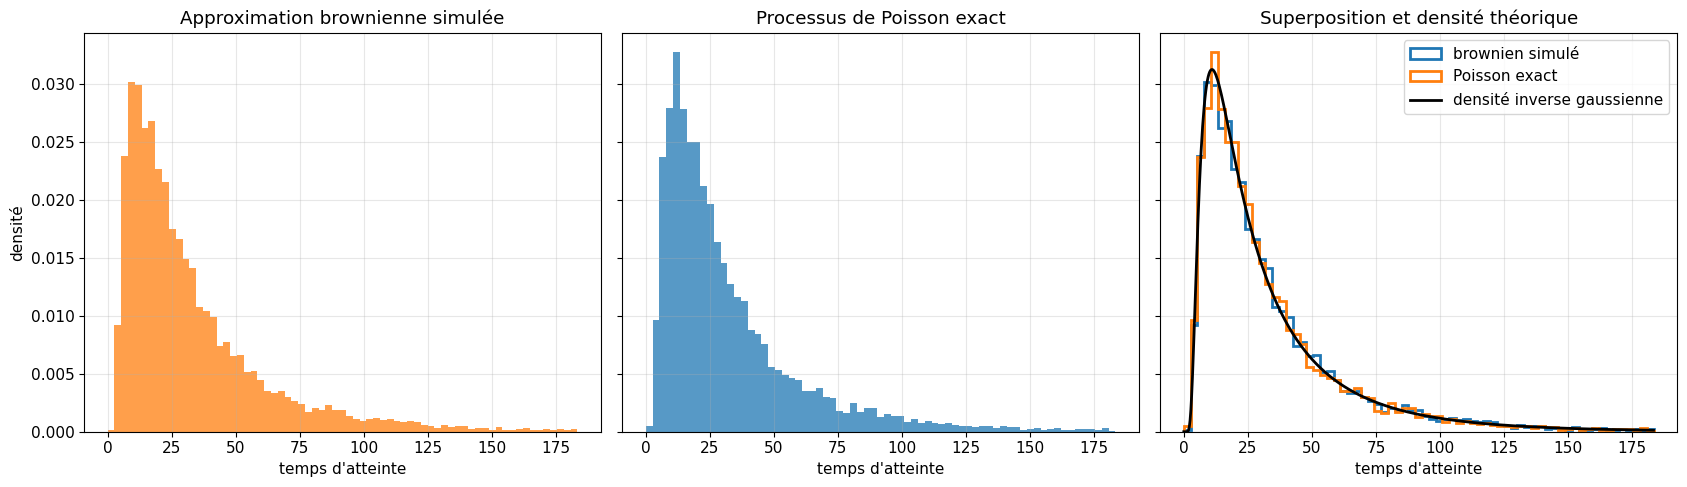

In [5]:
def simuler_temps_poisson_une_file(n_runs, q_init, lambda_plus, lambda_minus, rng, t_max=2_000.0):
    # Simule le temps d'atteinte de zéro pour une seule file birth-death.
    temps = np.empty(n_runs)
    for k in range(n_runs):
        q = q_init
        t = 0.0
        taux_total = lambda_plus + lambda_minus
        while q > 0 and t < t_max:
            t += rng.exponential(1.0 / taux_total)
            if rng.random() < lambda_plus / taux_total:
                q += 1
            else:
                q -= 1
        temps[k] = t
    return temps


def echantillon_inverse_gaussienne_brownienne(n_runs, x0, mu, sigma, rng):
    # Échantillonnage exact de T₀ pour le brownien avec drift négatif.
    moyenne = x0 / abs(mu)
    forme = x0**2 / sigma**2
    v = rng.normal(size=n_runs)
    y = v**2
    racine = np.sqrt(4 * moyenne * forme * y + moyenne**2 * y**2)
    x = moyenne + (moyenne**2 * y) / (2 * forme) - (moyenne / (2 * forme)) * racine
    u = rng.random(n_runs)
    return np.where(u <= moyenne / (moyenne + x), x, moyenne**2 / x)


N_sim = 10_000
rng = np.random.default_rng(SEED)
temps_bm = echantillon_inverse_gaussienne_brownienne(N_sim, Q0, MU, SIGMA, rng)
temps_poisson = simuler_temps_poisson_une_file(N_sim, Q0, LAMBDA_PLUS, LAMBDA_MINUS, rng)

bins = np.linspace(0, np.quantile(np.r_[temps_bm, temps_poisson], 0.995), 70)
t_pdf = np.linspace(0.01, bins[-1], 600)
pdf_theo = hitting_time_pdf_brownian(t_pdf, Q0, MU, SIGMA)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

axes[0].hist(temps_bm, bins=bins, density=True, color="tab:orange", alpha=0.75)
axes[0].set_title("Approximation brownienne simulée")
axes[0].set_xlabel("temps d'atteinte")
axes[0].set_ylabel("densité")

axes[1].hist(temps_poisson, bins=bins, density=True, color="tab:blue", alpha=0.75)
axes[1].set_title("Processus de Poisson exact")
axes[1].set_xlabel("temps d'atteinte")

axes[2].hist(temps_bm, bins=bins, density=True, histtype="step", linewidth=2, label="brownien simulé")
axes[2].hist(temps_poisson, bins=bins, density=True, histtype="step", linewidth=2, label="Poisson exact")
axes[2].plot(t_pdf, pdf_theo, color="black", linewidth=2, label="densité inverse gaussienne")
axes[2].set_title("Superposition et densité théorique")
axes[2].set_xlabel("temps d'atteinte")
axes[2].legend()

plt.tight_layout()
plt.show()


**Interprétation.** La densité inverse gaussienne décrit très bien
l'approximation brownienne. Le processus discret présente une forme proche,
mais pas identique : il ne peut atteindre zéro qu'après un nombre entier de
retraits nets, et sa dynamique reste contrainte par la granularité des sauts.


## Question 1.2.3.3 — Temps moyen et intervalle de confiance

On estime par Monte Carlo

$$
\mathbb{E}[T_{\min}]
=\mathbb{E}[\min(T_1,T_{-1})].
$$

Pour $n$ simulations indépendantes, l'intervalle de confiance asymptotique
à 95 % est

$$
\left[\widehat\mu_n-1.96\frac{\widehat\sigma_n}{\sqrt{n}},
\widehat\mu_n+1.96\frac{\widehat\sigma_n}{\sqrt{n}}\right].
$$

Pour une seule file brownienne de drift négatif, la formule théorique est

$$
\mathbb{E}[T_{\mathrm{single}}]=\frac{x_0}{|\mu|}.
$$


Estimation de E[T_min] : 18.6299
Écart-type empirique : 13.7059
IC 95 % : [18.3613, 18.8985]
E[T_single] brownien théorique : 33.3333


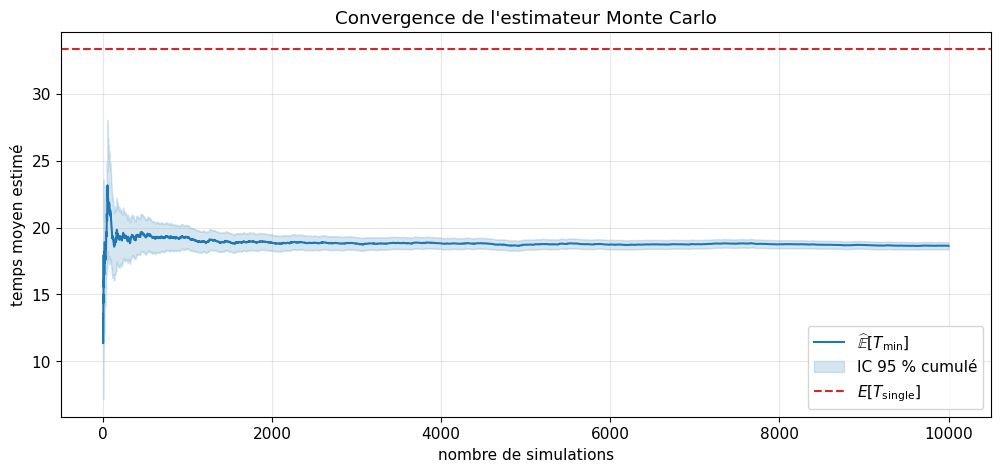

In [6]:
N_mc = 10_000
res_mc = batch_hitting_times(
    n_runs=N_mc,
    q1_init=Q0,
    q_neg1_init=Q0,
    lambda_plus=LAMBDA_PLUS,
    lambda_minus=LAMBDA_MINUS,
    seed=SEED,
)

temps_min = res_mc["hitting_times"]
print(f"Estimation de E[T_min] : {res_mc['mean_T']:.4f}")
print(f"Écart-type empirique : {res_mc['std_T']:.4f}")
print(f"IC 95 % : [{res_mc['ci_95'][0]:.4f}, {res_mc['ci_95'][1]:.4f}]")
print(f"E[T_single] brownien théorique : {hitting_time_mean_brownian(Q0, MU):.4f}")

n = np.arange(1, N_mc + 1)
moy_cum = np.cumsum(temps_min) / n
cum_sum = np.cumsum(temps_min)
cum_sum2 = np.cumsum(temps_min**2)
var_cum = np.zeros_like(moy_cum)
var_cum[1:] = (cum_sum2[1:] - cum_sum[1:]**2 / n[1:]) / (n[1:] - 1)
demi_largeur = 1.96 * np.sqrt(var_cum / np.maximum(n, 1))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(n, moy_cum, label=r"$\widehat{\mathbb{E}}[T_{\min}]$")
ax.fill_between(
    n[1:],
    moy_cum[1:] - demi_largeur[1:],
    moy_cum[1:] + demi_largeur[1:],
    color="tab:blue",
    alpha=0.18,
    label="IC 95 % cumulé",
)
ax.axhline(hitting_time_mean_brownian(Q0, MU), color="tab:red", linestyle="--", label=r"$E[T_{\mathrm{single}}]$")
ax.set_xlabel("nombre de simulations")
ax.set_ylabel("temps moyen estimé")
ax.set_title("Convergence de l'estimateur Monte Carlo")
ax.legend()
plt.show()


**Conclusion.** Le minimum de deux temps d'atteinte indépendants est
naturellement plus petit que le temps d'atteinte d'une file seule. La courbe
de convergence se stabilise autour de l'estimation Monte Carlo, tandis que la
largeur de l'intervalle de confiance décroît en $1/\sqrt{n}$.


## Question 1.2.3.4 — Temps moyen selon les conditions initiales

On balaie

$$
Q_1(0)\in\{2,4,\ldots,20\},\qquad
Q_{-1}(0)\in\{2,4,\ldots,20\}.
$$

Pour chaque point de la grille, on estime $\mathbb{E}[T_{\min}]$ par
Monte Carlo avec au moins $1000$ simulations.


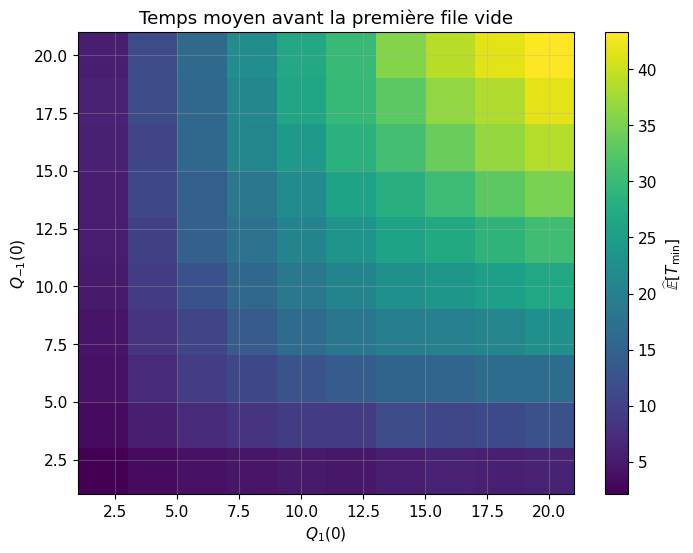

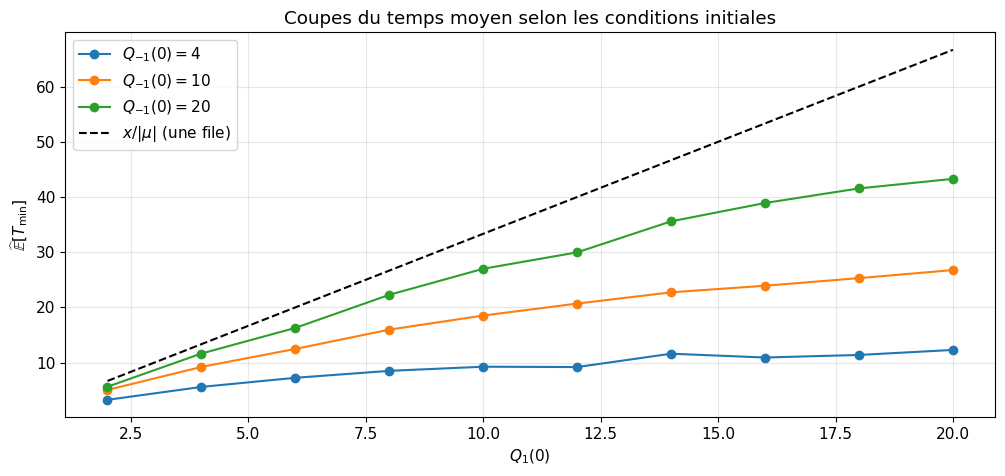

In [7]:
q_values = np.arange(2, 22, 2)
N_heatmap = 1_000

scan = scan_initial_conditions(
    q1_range=q_values,
    q_neg1_range=q_values,
    n_runs=N_heatmap,
    lambda_plus=LAMBDA_PLUS,
    lambda_minus=LAMBDA_MINUS,
    seed=SEED,
)

mean_T_grid = scan["mean_T_grid"]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    mean_T_grid,
    origin="lower",
    extent=[q_values[0]-1, q_values[-1]+1, q_values[0]-1, q_values[-1]+1],
    aspect="auto",
    cmap="viridis",
)
fig.colorbar(im, ax=ax, label=r"$\widehat{\mathbb{E}}[T_{\min}]$")
ax.set_xlabel(r"$Q_1(0)$")
ax.set_ylabel(r"$Q_{-1}(0)$")
ax.set_title("Temps moyen avant la première file vide")
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for qn_fixed in [4, 10, 20]:
    idx = np.where(q_values == qn_fixed)[0][0]
    ax.plot(q_values, mean_T_grid[idx, :], marker="o", label=fr"$Q_{{-1}}(0)={qn_fixed}$")

ax.plot(q_values, q_values / abs(MU), color="black", linestyle="--", label=r"$x/|\mu|$ (une file)")
ax.set_xlabel(r"$Q_1(0)$")
ax.set_ylabel(r"$\widehat{\mathbb{E}}[T_{\min}]$")
ax.set_title("Coupes du temps moyen selon les conditions initiales")
ax.legend()
plt.show()


**Interprétation.** Le temps moyen augmente avec les tailles initiales des
deux files. Les coupes restent sous la courbe $x/|\mu|$, car le système
s'arrête dès que l'une des deux files atteint zéro.


## Question 1.2.3.5 — Probabilité que $Q_1$ touche zéro en premier

On estime

$$
\mathbb{P}(T_1<T_{-1})
$$

sur la même grille de conditions initiales. Pour l'approximation brownienne,
l'expression utilisée est

$$
\mathbb{P}(T_1<T_{-1})
=\int_0^\infty f_{T_1}(t)\left(1-F_{T_{-1}}(t)\right)\,dt,
$$

où $f_{T_1}$ est la densité inverse gaussienne de $T_1$ et
$F_{T_{-1}}$ la fonction de répartition de $T_{-1}$.


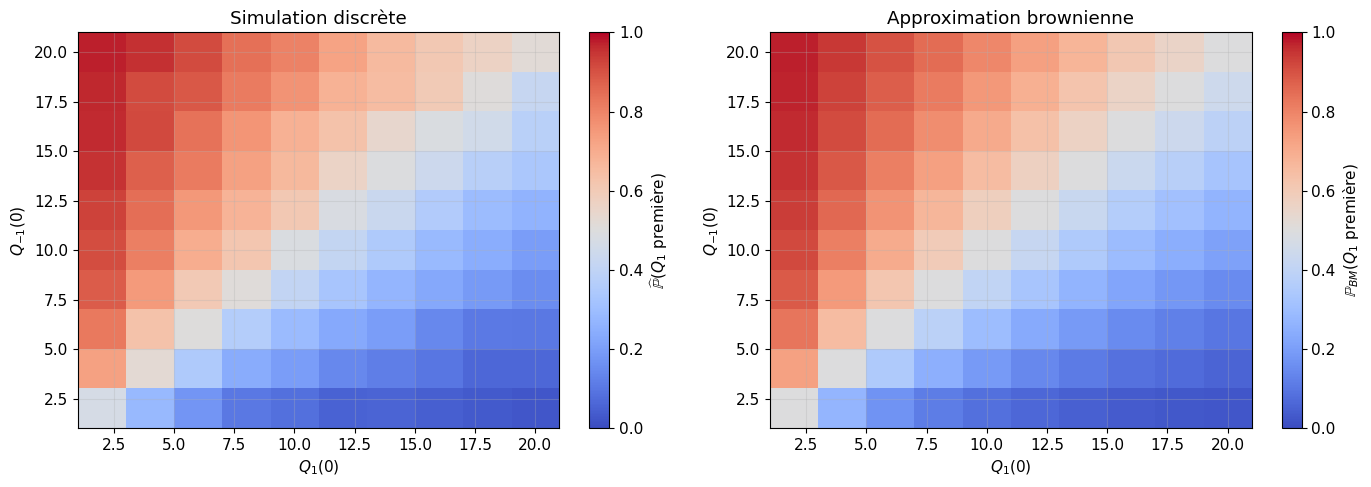

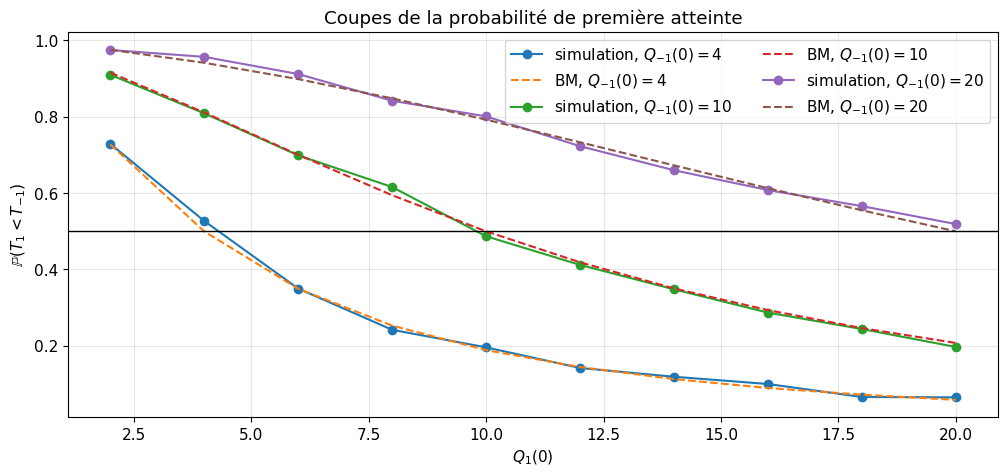

Probabilités simulées sur la diagonale : [0.47  0.527 0.503 0.508 0.487 0.484 0.493 0.487 0.506 0.519]
Écart maximal à 0.5 sur la diagonale : 0.030


In [8]:
prob_q1_grid = scan["prob_q1_grid"]

prob_bm_grid = np.zeros_like(prob_q1_grid)
for j, qn in enumerate(q_values):
    for i, q1 in enumerate(q_values):
        prob_bm_grid[j, i] = prob_q1_hits_first_brownian(q1, qn, MU, SIGMA)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(
    prob_q1_grid,
    origin="lower",
    extent=[q_values[0]-1, q_values[-1]+1, q_values[0]-1, q_values[-1]+1],
    vmin=0,
    vmax=1,
    cmap="coolwarm",
    aspect="auto",
)
fig.colorbar(im0, ax=axes[0], label=r"$\widehat{\mathbb{P}}(Q_1\ \mathrm{première})$")
axes[0].set_title("Simulation discrète")
axes[0].set_xlabel(r"$Q_1(0)$")
axes[0].set_ylabel(r"$Q_{-1}(0)$")

im1 = axes[1].imshow(
    prob_bm_grid,
    origin="lower",
    extent=[q_values[0]-1, q_values[-1]+1, q_values[0]-1, q_values[-1]+1],
    vmin=0,
    vmax=1,
    cmap="coolwarm",
    aspect="auto",
)
fig.colorbar(im1, ax=axes[1], label=r"$\mathbb{P}_{BM}(Q_1\ \mathrm{première})$")
axes[1].set_title("Approximation brownienne")
axes[1].set_xlabel(r"$Q_1(0)$")
axes[1].set_ylabel(r"$Q_{-1}(0)$")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for qn_fixed in [4, 10, 20]:
    idx = np.where(q_values == qn_fixed)[0][0]
    ax.plot(q_values, prob_q1_grid[idx, :], marker="o", label=fr"simulation, $Q_{{-1}}(0)={qn_fixed}$")
    ax.plot(q_values, prob_bm_grid[idx, :], linestyle="--", label=fr"BM, $Q_{{-1}}(0)={qn_fixed}$")

ax.axhline(0.5, color="black", linewidth=1)
ax.set_xlabel(r"$Q_1(0)$")
ax.set_ylabel(r"$\mathbb{P}(T_1<T_{-1})$")
ax.set_title("Coupes de la probabilité de première atteinte")
ax.legend(ncol=2)
plt.show()

diag = np.diag(prob_q1_grid)
print("Probabilités simulées sur la diagonale :", np.round(diag, 3))
print(f"Écart maximal à 0.5 sur la diagonale : {np.max(np.abs(diag - 0.5)):.3f}")


**Conclusion.** Sur la diagonale $Q_1(0)=Q_{-1}(0)$, la symétrie impose
$\mathbb{P}(T_1<T_{-1})\approx 1/2$, à l'erreur Monte Carlo près. Lorsque
$Q_1(0)$ augmente à $Q_{-1}(0)$ fixé, $Q_1$ est plus loin du bord et sa
probabilité d'être la première file vide diminue.


# Section 1.2.4 — Deuxième modélisation : files Hawkes couplées

Les ajouts restent au taux constant
$\mu^+$, tandis que les retraits ont une intensité de Hawkes exponentielle :

$$
\lambda^-(t)
=\mu^- -\int_0^t \alpha e^{-\beta(t-s)}\,dN_s^+
+\int_0^t \alpha e^{-\beta(t-s)}\,dN_s^- .
$$

L'interprétation est la suivante :

- un ajout augmente la taille de la file et **diminue** temporairement le taux
  de retrait futur ;
- un retrait signale une consommation en cours et **augmente** temporairement
  le taux de retrait futur.


In [9]:
import sys
sys.path.insert(0, '.')

import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from model.hawkes import (
        simulate_hawkes_queue,
        simulate_coupled_hawkes,
        hawkes_stationary_intensity,
    )
except ModuleNotFoundError:
    from model.hawkes import (
        simulate_hawkes_queue,
        simulate_coupled_hawkes,
        hawkes_stationary_intensity,
    )

from model.hitting_times import simulate_until_hit_zero

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.framealpha': 0.92,
})

COLORS = {
    'hawkes': '#7A3E9D',
    'hawkes2': '#C44E52',
    'poisson': '#2F6B9A',
    'poisson2': '#E08D3C',
    'theory': '#222222',
    'green': '#3F8F5F',
    'gray': '#8A8A8A',
}


def style_axes(ax, xlabel=None, ylabel=None, title=None):
    """Applique un style homogène et lisible aux figures du notebook."""
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title, pad=10, fontweight='semibold')
    ax.grid(True, alpha=0.28)
    ax.margins(x=0.01)
    return ax


def add_panel_label(ax, label):
    ax.text(
        0.015,
        0.96,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=12,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='0.85', alpha=0.9),
    )


def intervalle_confiance_95(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    moyenne = arr.mean()
    ecart_type = arr.std(ddof=1)
    demi_largeur = 1.96 * ecart_type / np.sqrt(len(arr))
    return moyenne, ecart_type, moyenne - demi_largeur, moyenne + demi_largeur, len(arr)

SEED = 42
MU_PLUS = 1.2
MU_MINUS = 1.5
ALPHA = 0.3
BETA = 0.5
RATIO = ALPHA / BETA
Q0 = 10

print(f"Paramètres : μ⁺={MU_PLUS}, μ⁻={MU_MINUS}, α={ALPHA}, β={BETA}, α/β={RATIO:.2f}")
print("Signature simulate_hawkes_queue :", inspect.signature(simulate_hawkes_queue))
print("Signature simulate_coupled_hawkes :", inspect.signature(simulate_coupled_hawkes))


Paramètres : μ⁺=1.2, μ⁻=1.5, α=0.3, β=0.5, α/β=0.60
Signature simulate_hawkes_queue : (q_init: int = 10, mu_plus: float = 1.2, mu_minus: float = 1.5, alpha: float = 0.3, beta: float = 0.5, T_max: float = 1000.0, rng: Optional[numpy.random._generator.Generator] = None, stop_at_zero: bool = True, sign_convention: str = 'v4') -> model.hawkes.HawkesQueueResult
Signature simulate_coupled_hawkes : (q1_init: int = 10, q_neg1_init: int = 10, mu_plus: float = 1.2, mu_minus: float = 1.5, alpha: float = 0.3, beta: float = 0.5, T_max: float = 1000.0, rng: Optional[numpy.random._generator.Generator] = None, stop_at_zero: bool = True, sign_convention: str = 'v4') -> model.hawkes.CoupledHawkesResult


## Vérification des signes et implémentation itérative

On pose

$$
H(t)=
-\sum_{s<t,\ \Delta N_s^+=1}\alpha e^{-\beta(t-s)}
+\sum_{s<t,\ \Delta N_s^-=1}\alpha e^{-\beta(t-s)},
\qquad
\lambda^-(t)=\mu^-+H(t).
$$

Entre deux événements $t_k$ et $t_{k+1}=t_k+\delta t_k$,

$$
H(t_{k+1}^-)=H(t_k^+)e^{-\beta\delta t_k}.
$$

Au saut $t_{k+1}$, on met ensuite à jour

$$
H(t_{k+1}^+)=
\begin{cases}
H(t_{k+1}^-)-\alpha, & \text{ajout},\\
H(t_{k+1}^-)+\alpha, & \text{retrait}.
\end{cases}
$$

On fait
décroître l'état $H$, on accepte ou rejette un candidat par thinning, puis
on applique le saut $\pm\alpha$.


In [10]:
m_theo = hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA)
print(f"Moyenne stationnaire théorique : m⁻ = {m_theo:.4f}")
print(f"Drift effectif sans bord : μ⁺ - m⁻ = {MU_PLUS - m_theo:.4f}")

source = inspect.getsource(simulate_hawkes_queue)
checks = {
    "ajout v4 : H -= α": 'add_jump = -alpha if convention == "v4" else alpha' in source,
    "retrait v4 : H += α": 'remove_jump = alpha if convention == "v4" else -alpha' in source,
}
for nom, ok in checks.items():
    print(f"{nom:22s} -> {'OK' if ok else 'à vérifier'}")


Moyenne stationnaire théorique : m⁻ = 1.9500
Drift effectif sans bord : μ⁺ - m⁻ = -0.7500
ajout v4 : H -= α      -> OK
retrait v4 : H += α    -> OK


## Condition de stationnarité

On note

$$
r=\int_0^\infty \alpha e^{-\beta u}\,du=\frac{\alpha}{\beta}.
$$

Donc,

$$
\lambda^-(t)=\mu^- - \phi \ast dN^+(t) + \phi \ast dN^-(t).
$$

En régime stationnaire, si
$m^- = \mathbb{E}[\lambda^-(t)]$, alors

$$
\frac{\mathbb{E}[dN_t^+]}{dt}=\mu^+,
\qquad
\frac{\mathbb{E}[dN_t^-]}{dt}=m^-.
$$

En prenant l'espérance dans l'équation de l'intensité, on obtient

$$
m^- = \mu^- - r\mu^+ + r m^-.
$$

Donc

$$
(1-r)m^- = \mu^- - r\mu^+,
\qquad
m^- = \frac{\mu^- - r\mu^+}{1-r}.
$$

Avec les paramètres de référence,

$$
r=\frac{0.3}{0.5}=0.6,
\qquad
m^- = \frac{1.5-0.6\times1.2}{1-0.6}=1.95.
$$

La condition de stabilité est $r<1$. Elle correspond au fait que la masse
$L^1$ du noyau excitateur est strictement inférieure à un ; dans un Hawkes
multivarié, on remplace cette quantité par le rayon spectral de la matrice des
masses de noyaux.

**Point important.** Cette formule décrit l'intensité Hawkes linéaire sans
bord de file. Elle ne doit pas être confondue avec la moyenne empirique d'une
file contrainte par $Q(t)\geq 0$, car lorsque $Q(t)=0$, les retraits sont
interdits et l'intensité effective est abaissée.


## Question 1.2.4.1 — Simulation et estimation de $\bar{\lambda}^-$

Pour vérifier la formule théorique de $m^-$, on estime la moyenne temporelle

$$
\bar{\lambda}^-_T
=
\frac{1}{T-T_{\mathrm{burn}}}
\int_{T_{\mathrm{burn}}}^{T}\lambda^-(t)\,dt.
$$

La moyenne doit être calculée avec l'évolution exponentielle de l'intensité entre deux événements. Si $H_i=H(t_i^+)$, alors pour $0\leq u\leq \Delta t_i$ :

$$
\lambda^-(t_i+u)=\max\left(0,\mu^-+H_i e^{-\beta u}\right).
$$

On intègre donc exactement cette expression sur chaque intervalle inter-événement. Toutes les simulations Hawkes utilisent `stop_at_zero=True`. Pour éviter que le bord $Q=0$ ne perturbe l'estimation de $m^-$, on prend une grande file initiale $Q(0)=5000$ ; avec les paramètres ci-dessous, la file ne touche pas zéro sur l'horizon de vérification.


m⁻ théorique : 1.9500
λ̄⁻ exacte après burn-in : 1.9548
Écart relatif : +0.25%
Grande file : hit_zero=False, min(Q)=1205
File q_init=50 : hit_zero=True, T0=124.9520


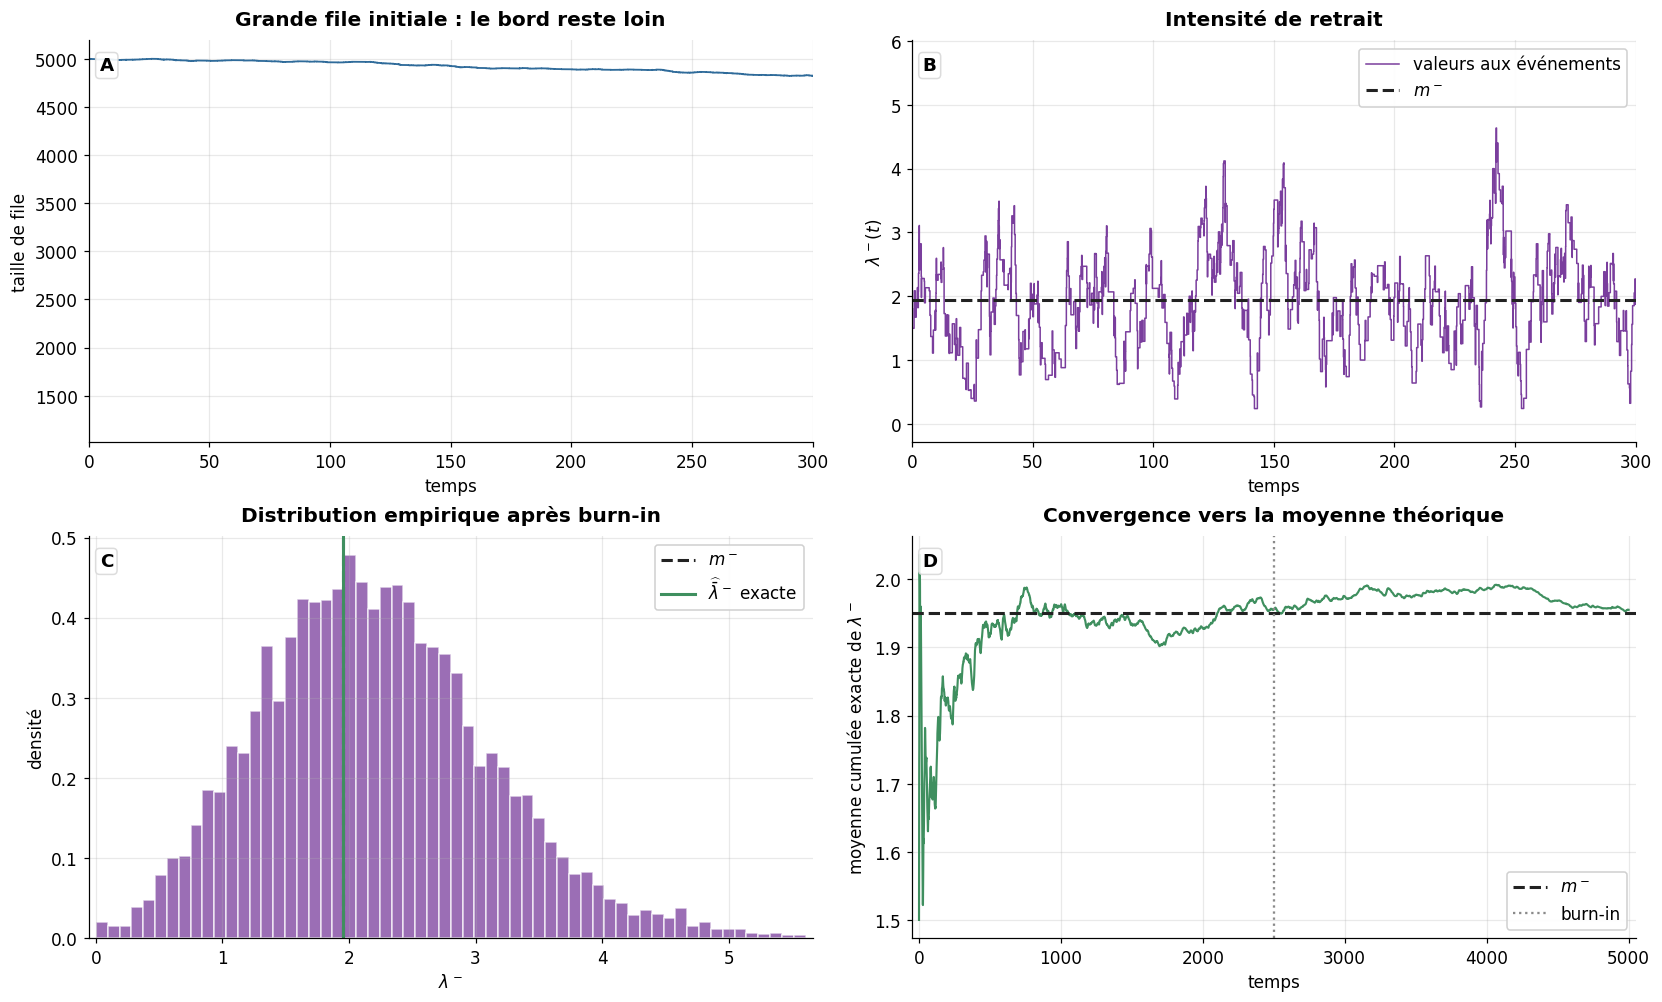

In [11]:
def reconstruire_H(res, alpha=ALPHA, beta=BETA):
    """Reconstruit H(t_i^+) à partir des temps et types d'événements."""
    H = 0.0
    H_path = [H]
    for k in range(1, len(res.times)):
        dt = res.times[k] - res.times[k - 1]
        H *= np.exp(-beta * dt)
        if res.event_types[k] == 1:
            H -= alpha
        elif res.event_types[k] == -1:
            H += alpha
        H_path.append(H)
    return np.asarray(H_path)


def integrale_lambda_intervalle(H, a, b, mu_minus=MU_MINUS, beta=BETA, clipped=True):
    """Intègre λ(u)=max(0, μ⁻+H exp(-βu)) ou sa version linéaire sur [a,b]."""
    if b <= a:
        return 0.0

    def integral_linear(left, right):
        return mu_minus * (right - left) + H * (np.exp(-beta * left) - np.exp(-beta * right)) / beta

    if not clipped:
        return integral_linear(a, b)

    # Si H>=0, λ est positive. Si H<0, λ croît vers μ⁻ et peut franchir 0.
    if H >= 0 or mu_minus + H * np.exp(-beta * a) >= 0:
        return integral_linear(a, b)

    u0 = np.log((-H) / mu_minus) / beta
    if u0 >= b:
        return 0.0
    return integral_linear(max(a, u0), b)


def moyenne_temporelle_exacte(res, horizon, burn_in=0.0, clipped=True):
    """Moyenne temporelle exacte de λ⁻, en tenant compte de la décroissance exponentielle."""
    times = np.asarray(res.times)
    H_path = reconstruire_H(res)
    total = 0.0
    duration = 0.0

    for i, H in enumerate(H_path):
        start = times[i]
        end = times[i + 1] if i + 1 < len(times) else horizon
        left_abs = max(start, burn_in)
        right_abs = min(end, horizon)
        if right_abs <= left_abs:
            continue
        total += integrale_lambda_intervalle(H, left_abs - start, right_abs - start, clipped=clipped)
        duration += right_abs - left_abs

    return total / duration


def moyenne_cumulee_exacte(res, horizon, clipped=True):
    """Moyenne cumulée exacte de λ⁻ depuis 0 jusqu'à chaque temps d'événement."""
    times = np.asarray(res.times)
    H_path = reconstruire_H(res)
    running_times = []
    running_means = []
    total = 0.0
    duration = 0.0

    for i, H in enumerate(H_path):
        start = times[i]
        end = times[i + 1] if i + 1 < len(times) else horizon
        end = min(end, horizon)
        if end <= start:
            continue
        total += integrale_lambda_intervalle(H, 0.0, end - start, clipped=clipped)
        duration += end - start
        running_times.append(end)
        running_means.append(total / duration)
        if end >= horizon:
            break

    return np.asarray(running_times), np.asarray(running_means)


rng = np.random.default_rng(SEED)
T_long = 5_000.0
BURN_IN = T_long / 2
Q_STATIONNAIRE = 5_000
m_theo = hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA)

res_long = simulate_hawkes_queue(
    q_init=Q_STATIONNAIRE,
    mu_plus=MU_PLUS,
    mu_minus=MU_MINUS,
    alpha=ALPHA,
    beta=BETA,
    T_max=T_long,
    rng=rng,
    stop_at_zero=True,
)

lambda_bar = moyenne_temporelle_exacte(res_long, T_long, burn_in=BURN_IN, clipped=True)
running_t, running_mean = moyenne_cumulee_exacte(res_long, T_long, clipped=True)

res_queue_50 = simulate_hawkes_queue(
    q_init=50,
    mu_plus=MU_PLUS,
    mu_minus=MU_MINUS,
    alpha=ALPHA,
    beta=BETA,
    T_max=T_long,
    rng=np.random.default_rng(SEED),
    stop_at_zero=True,
)

print(f"m⁻ théorique : {m_theo:.4f}")
print(f"λ̄⁻ exacte après burn-in : {lambda_bar:.4f}")
print(f"Écart relatif : {(lambda_bar / m_theo - 1):+.2%}")
print(f"Grande file : hit_zero={res_long.hit_zero}, min(Q)={res_long.queue_path.min():.0f}")
print(f"File q_init=50 : hit_zero={res_queue_50.hit_zero}, T0={res_queue_50.hitting_time:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(15, 9), layout='constrained')

removals = np.cumsum(res_long.event_types == -1)
axes[0, 0].step(res_long.times, res_long.queue_path, where="post", color=COLORS['poisson'], linewidth=1.2)
axes[0, 0].set_xlim(0, 300)
style_axes(axes[0, 0], "temps", "taille de file", "Grande file initiale : le bord reste loin")
add_panel_label(axes[0, 0], "A")

axes[0, 1].step(res_long.times, res_long.lambda_minus_path, where="post", color=COLORS['hawkes'], linewidth=1.0, label="valeurs aux événements")
axes[0, 1].axhline(m_theo, color=COLORS['theory'], linestyle="--", linewidth=2.0, label=r"$m^-$")
axes[0, 1].set_xlim(0, 300)
style_axes(axes[0, 1], "temps", r"$\lambda^-(t)$", "Intensité de retrait")
axes[0, 1].legend(frameon=True)
add_panel_label(axes[0, 1], "B")

masque_stationnaire = res_long.times > BURN_IN
axes[1, 0].hist(res_long.lambda_minus_path[masque_stationnaire], bins=60, density=True,
                alpha=0.75, color=COLORS['hawkes'], edgecolor="white")
axes[1, 0].axvline(m_theo, color=COLORS['theory'], linestyle="--", linewidth=2.0, label=r"$m^-$")
axes[1, 0].axvline(lambda_bar, color=COLORS['green'], linewidth=2.0, label=r"$\widehat{\bar\lambda}^-$ exacte")
style_axes(axes[1, 0], r"$\lambda^-$", "densité", "Distribution empirique après burn-in")
axes[1, 0].legend(frameon=True)
add_panel_label(axes[1, 0], "C")

axes[1, 1].plot(running_t, running_mean, linewidth=1.4, color=COLORS['green'])
axes[1, 1].axhline(m_theo, color=COLORS['theory'], linestyle="--", linewidth=2.0, label=r"$m^-$")
axes[1, 1].axvline(BURN_IN, color=COLORS['gray'], linestyle=":", linewidth=1.5, label="burn-in")
style_axes(axes[1, 1], "temps", r"moyenne cumulée exacte de $\lambda^-$", "Convergence vers la moyenne théorique")
axes[1, 1].legend(frameon=True)
add_panel_label(axes[1, 1], "D")

plt.show()


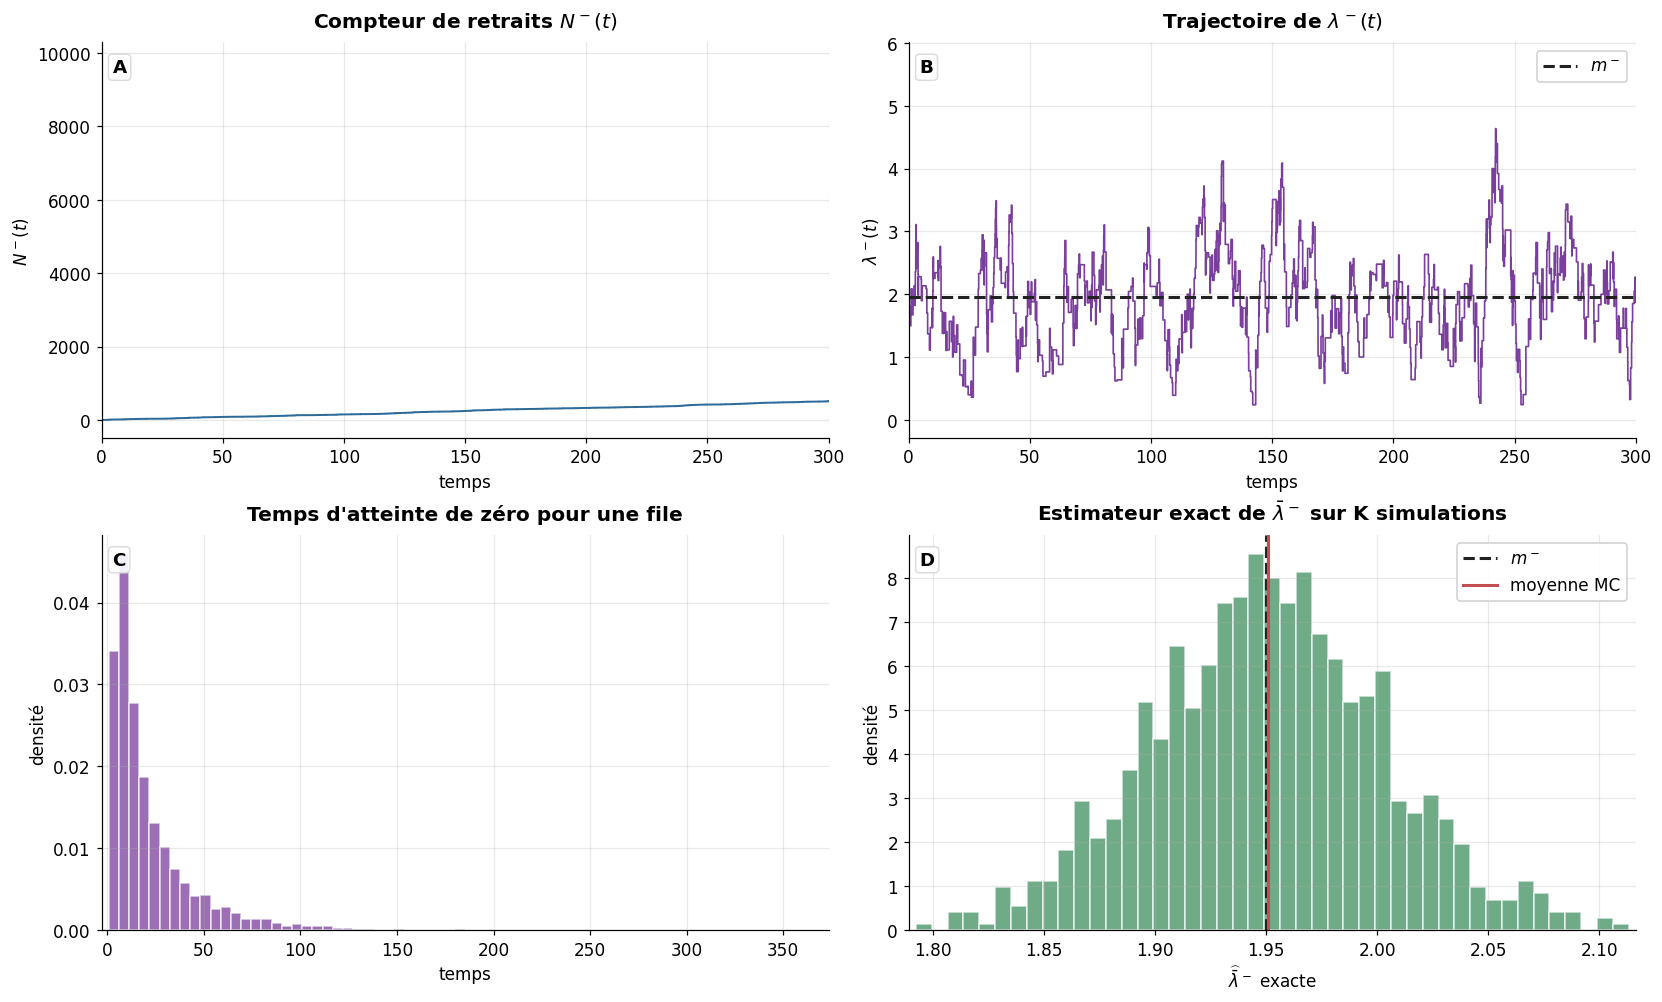

Moyenne des λ̄⁻ exactes : 1.9509
IC 95 % : [1.9476, 1.9541]
m⁻ théorique : 1.9500
Écart à m⁻ : +0.0009 (+0.04%)
m⁻ dans l'IC ? True


In [12]:
# Figure de synthèse en quatre panneaux, dans l'esprit de la Figure 4 du sujet.
K = 1_000
N_hit = 5_000
rng = np.random.default_rng(SEED)

lambda_moyennes = np.empty(K)
for k in range(K):
    r = simulate_hawkes_queue(
        q_init=Q_STATIONNAIRE,
        mu_plus=MU_PLUS,
        mu_minus=MU_MINUS,
        alpha=ALPHA,
        beta=BETA,
        T_max=T_long,
        rng=rng,
        stop_at_zero=True,
    )
    lambda_moyennes[k] = moyenne_temporelle_exacte(r, T_long, burn_in=BURN_IN, clipped=True)

temps_hawkes_simple = np.empty(N_hit)
for k in range(N_hit):
    r = simulate_hawkes_queue(
        q_init=Q0,
        mu_plus=MU_PLUS,
        mu_minus=MU_MINUS,
        alpha=ALPHA,
        beta=BETA,
        T_max=2_000.0,
        rng=rng,
        stop_at_zero=True,
    )
    temps_hawkes_simple[k] = r.hitting_time

fig, axes = plt.subplots(2, 2, figsize=(15, 9), layout='constrained')

axes[0, 0].step(res_long.times, removals, where="post", color=COLORS['poisson'], linewidth=1.3)
axes[0, 0].set_xlim(0, 300)
style_axes(axes[0, 0], "temps", r"$N^-(t)$", r"Compteur de retraits $N^-(t)$")
add_panel_label(axes[0, 0], "A")

axes[0, 1].step(res_long.times, res_long.lambda_minus_path, where="post", color=COLORS['hawkes'], linewidth=1.1)
axes[0, 1].axhline(m_theo, color=COLORS['theory'], linestyle="--", linewidth=2.0, label=r"$m^-$")
axes[0, 1].set_xlim(0, 300)
style_axes(axes[0, 1], "temps", r"$\lambda^-(t)$", r"Trajectoire de $\lambda^-(t)$")
axes[0, 1].legend(frameon=True)
add_panel_label(axes[0, 1], "B")

axes[1, 0].hist(temps_hawkes_simple, bins=70, density=True, color=COLORS['hawkes'], alpha=0.75, edgecolor='white')
style_axes(axes[1, 0], "temps", "densité", "Temps d'atteinte de zéro pour une file")
add_panel_label(axes[1, 0], "C")

moy = np.nanmean(lambda_moyennes)
std = np.nanstd(lambda_moyennes, ddof=1)
ic = 1.96 * std / np.sqrt(np.sum(~np.isnan(lambda_moyennes)))
axes[1, 1].hist(lambda_moyennes, bins=45, density=True, color=COLORS['green'], alpha=0.75, edgecolor='white')
axes[1, 1].axvline(m_theo, color=COLORS['theory'], linestyle="--", linewidth=2.0, label=r"$m^-$")
axes[1, 1].axvline(moy, color=COLORS['hawkes2'], linewidth=2.0, label=r"moyenne MC")
style_axes(axes[1, 1], r"$\widehat{\bar\lambda}^-$ exacte", "densité", r"Estimateur exact de $\bar\lambda^-$ sur K simulations")
axes[1, 1].legend(frameon=True)
add_panel_label(axes[1, 1], "D")

plt.show()

print(f"Moyenne des λ̄⁻ exactes : {moy:.4f}")
print(f"IC 95 % : [{moy - ic:.4f}, {moy + ic:.4f}]")
print(f"m⁻ théorique : {m_theo:.4f}")
print(f"Écart à m⁻ : {moy - m_theo:+.4f} ({(moy / m_theo - 1):+.2%})")
print(f"m⁻ dans l'IC ? {moy - ic <= m_theo <= moy + ic}")


**Interprétation.** La moyenne temporelle de $\lambda^-$ est calculée par intégration exacte de la décroissance exponentielle entre événements, puis moyennée après burn-in. Avec la grande file initiale, le bord $Q=0$ ne perturbe pas la simulation : l'estimateur exact $\widehat{\bar\lambda}^-$ converge vers la valeur théorique $m^-=1.95$. La vérification pertinente est donc la couverture de $m^-$ par l'intervalle de confiance Monte Carlo.

## Question 1.2.4.2 — Distribution des temps d'atteinte de zéro, file Hawkes seule

On simule au moins $5000$ temps d'atteinte pour une file Hawkes partant de
$q_{\mathrm{init}}=10$. On compare ensuite à une file de Poisson ayant le
même drift effectif, c'est-à-dire le même taux d'ajout $\mu^+$ et un taux
de retrait égal à $m^-$.


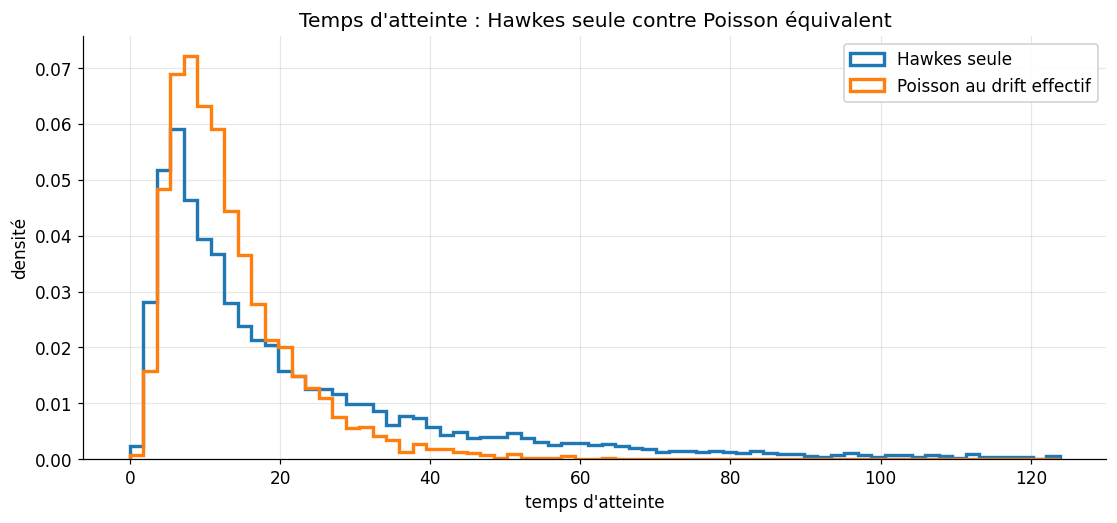

,modèle,moyenne,écart-type,n
0,Hawkes seule,22.822952,25.844070,5000
1,Poisson au drift effectif,13.283788,8.722286,5000


In [13]:
def simuler_temps_poisson_une_file(n_runs, q_init, lambda_plus, lambda_minus, rng, t_max=2_000.0):
    temps = np.empty(n_runs)
    for k in range(n_runs):
        q = q_init
        t = 0.0
        total = lambda_plus + lambda_minus
        while q > 0 and t < t_max:
            t += rng.exponential(1.0 / total)
            q += 1 if rng.random() < lambda_plus / total else -1
        temps[k] = t
    return temps


rng = np.random.default_rng(SEED)
N_sim = 5_000
lambda_eff = hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA)

# Si la cellule précédente n'a pas été exécutée, on recalcule les temps Hawkes.
if "temps_hawkes_simple" not in globals() or len(temps_hawkes_simple) < N_sim:
    temps_hawkes_simple = np.empty(N_sim)
    for k in range(N_sim):
        r = simulate_hawkes_queue(
            q_init=Q0,
            mu_plus=MU_PLUS,
            mu_minus=MU_MINUS,
            alpha=ALPHA,
            beta=BETA,
            T_max=2_000.0,
            rng=rng,
            stop_at_zero=True,
        )
        temps_hawkes_simple[k] = r.hitting_time

temps_poisson_eff = simuler_temps_poisson_une_file(N_sim, Q0, MU_PLUS, lambda_eff, rng)

bins = np.linspace(0, np.quantile(np.r_[temps_hawkes_simple, temps_poisson_eff], 0.995), 70)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(temps_hawkes_simple, bins=bins, density=True, histtype="step", linewidth=2.2, label="Hawkes seule")
ax.hist(temps_poisson_eff, bins=bins, density=True, histtype="step", linewidth=2.2, label="Poisson au drift effectif")
ax.set_xlabel("temps d'atteinte")
ax.set_ylabel("densité")
ax.set_title("Temps d'atteinte : Hawkes seule contre Poisson équivalent")
ax.legend()
plt.show()

pd.DataFrame({
    "modèle": ["Hawkes seule", "Poisson au drift effectif"],
    "moyenne": [temps_hawkes_simple.mean(), temps_poisson_eff.mean()],
    "écart-type": [temps_hawkes_simple.std(ddof=1), temps_poisson_eff.std(ddof=1)],
    "n": [len(temps_hawkes_simple), len(temps_poisson_eff)],
})


**Conclusion.** Le modèle de Hawkes ne modifie pas seulement le drift moyen :
il introduit des grappes de retraits et donc une distribution de temps
d'atteinte plus asymétrique qu'un modèle de Poisson. La comparaison au Poisson
de taux $m^-$ sert ici de référence sans dépendance temporelle.


## Question 1.2.4.3 — Deux files Hawkes couplées

L'équation de couplage (3) rend les retraits des deux premières limites
dépendants. Ici, l'état de retrait de chaque
file reçoit une contribution négative après un ajout et positive après un
retrait. L'effet croisé transmet donc les vagues de retraits entre les deux
côtés du carnet.

On simule les deux files, puis on visualise les trajectoires, les intensités
et la corrélation empirique entre $Q_1$ et $Q_{-1}$.


c:\Users\zhang\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\zhang\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


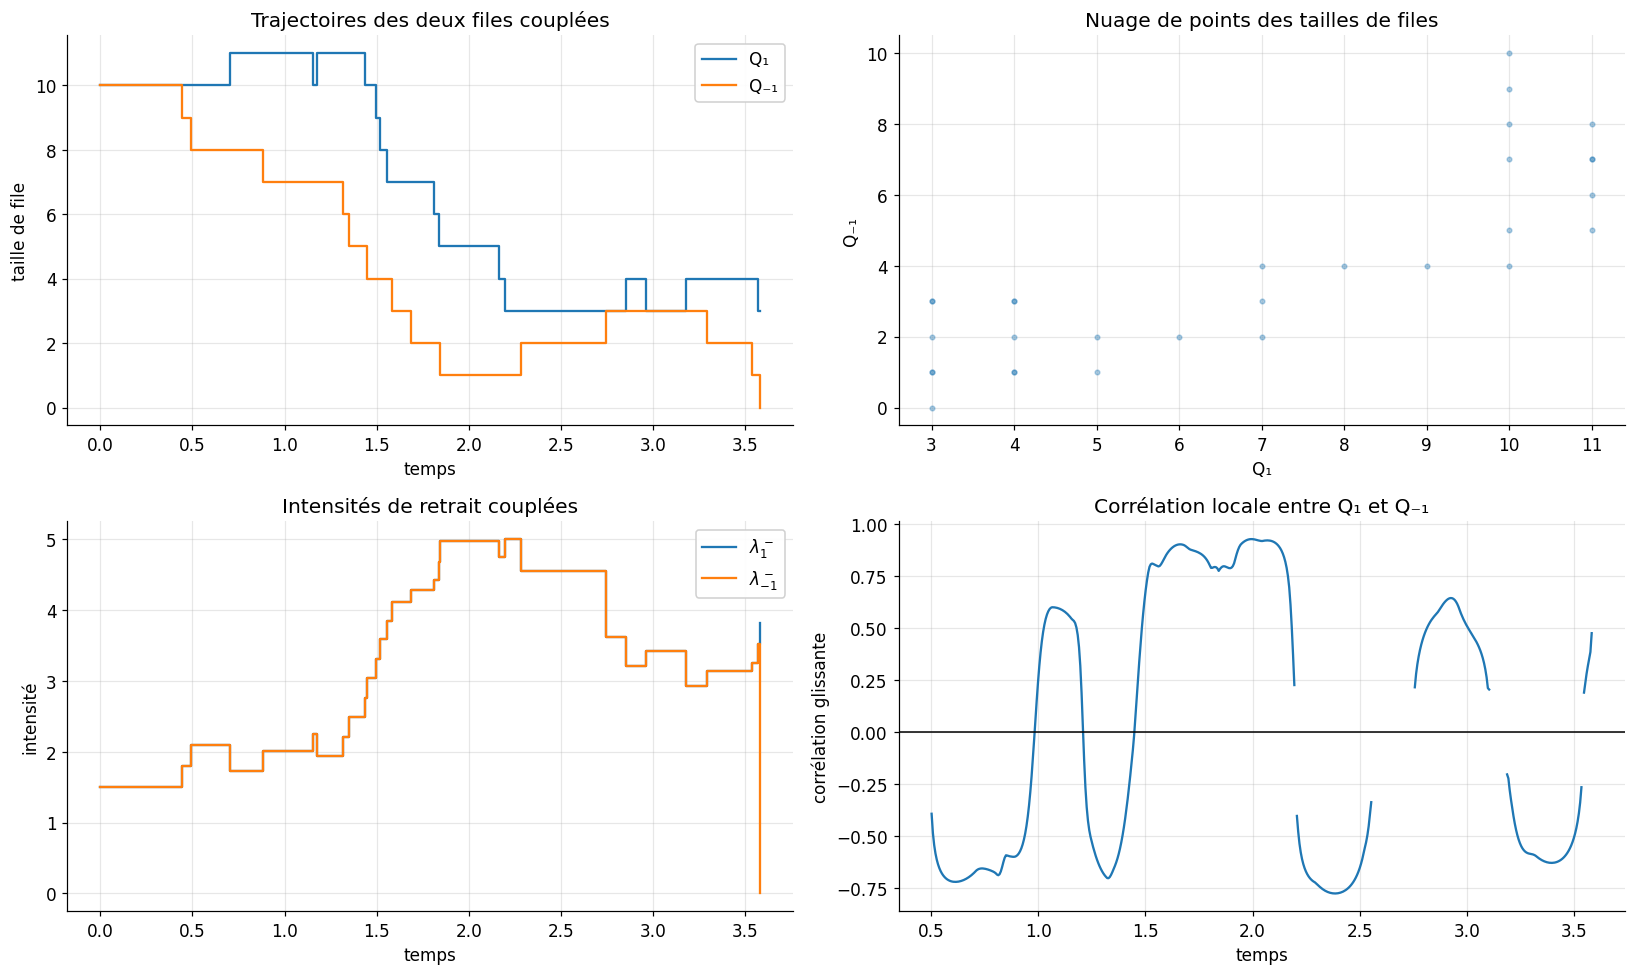

Corrélation globale interpolée : 0.863


In [14]:
rng = np.random.default_rng(SEED)
res_couple = simulate_coupled_hawkes(
    q1_init=Q0,
    q_neg1_init=Q0,
    mu_plus=MU_PLUS,
    mu_minus=MU_MINUS,
    alpha=ALPHA,
    beta=BETA,
    T_max=300.0,
    rng=rng,
    stop_at_zero=True,
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].step(res_couple.times, res_couple.q1_path, where="post", label="Q₁")
axes[0, 0].step(res_couple.times, res_couple.q_neg1_path, where="post", label="Q₋₁")
axes[0, 0].set_xlabel("temps")
axes[0, 0].set_ylabel("taille de file")
axes[0, 0].set_title("Trajectoires des deux files couplées")
axes[0, 0].legend()

axes[0, 1].plot(res_couple.q1_path, res_couple.q_neg1_path, ".", alpha=0.35)
axes[0, 1].set_xlabel("Q₁")
axes[0, 1].set_ylabel("Q₋₁")
axes[0, 1].set_title("Nuage de points des tailles de files")

axes[1, 0].step(res_couple.times, res_couple.lam_minus_1_path, where="post", label=r"$\lambda^-_1$")
axes[1, 0].step(res_couple.times, res_couple.lam_minus_neg1_path, where="post", label=r"$\lambda^-_{-1}$")
axes[1, 0].set_xlabel("temps")
axes[1, 0].set_ylabel("intensité")
axes[1, 0].set_title("Intensités de retrait couplées")
axes[1, 0].legend()

grille = np.linspace(res_couple.times[0], res_couple.times[-1], 600)
q1_interp = np.interp(grille, res_couple.times, res_couple.q1_path)
qn_interp = np.interp(grille, res_couple.times, res_couple.q_neg1_path)
fenetre = 60
corr_glissante = np.full(len(grille), np.nan)
for i in range(fenetre, len(grille)):
    corr_glissante[i] = np.corrcoef(q1_interp[i-fenetre:i], qn_interp[i-fenetre:i])[0, 1]

axes[1, 1].plot(grille, corr_glissante)
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_xlabel("temps")
axes[1, 1].set_ylabel("corrélation glissante")
axes[1, 1].set_title("Corrélation locale entre Q₁ et Q₋₁")

plt.tight_layout()
plt.show()

print(f"Corrélation globale interpolée : {np.corrcoef(q1_interp, qn_interp)[0, 1]:.3f}")


**Interprétation.** Les intensités réagissent aux événements des deux files,
ce qui crée une dépendance visible dans les trajectoires. La corrélation
glissante n'est pas constante : elle dépend des épisodes de retraits groupés
et des périodes de reconstitution des files.


## Question 1.2.4.4 — Temps d'atteinte des deux files couplées

On simule le temps

$$
T_{\min}^{H,c}=\min(T_1^H,T_{-1}^H)
$$

pour le système Hawkes couplé, puis on le compare à la file Hawkes seule et
au modèle de Poisson indépendant de la section 1.2.3.


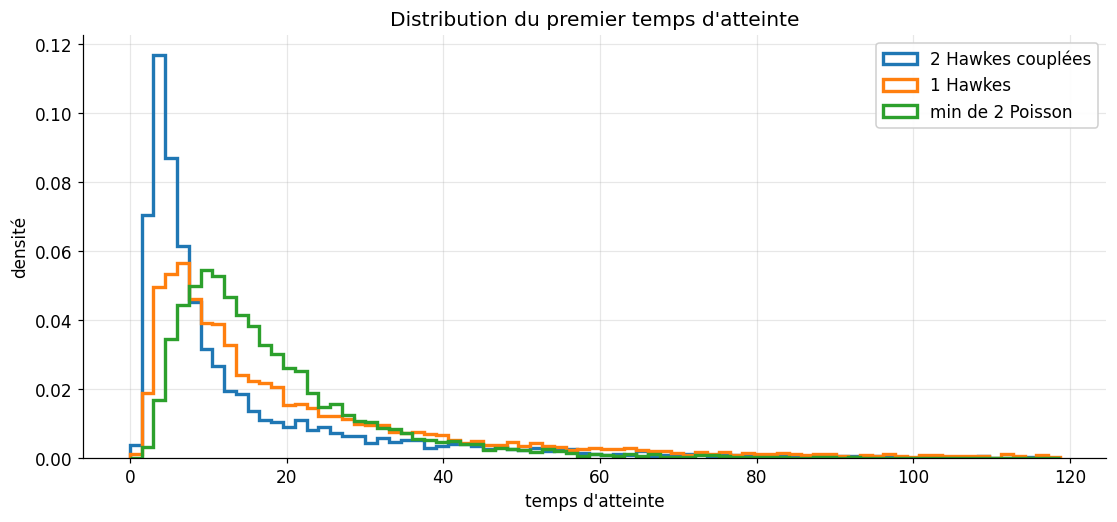

,modèle,moyenne,écart-type,n
0,2 Hawkes couplées,14.807327,18.358657,5000
1,1 Hawkes,22.822952,25.844070,5000
2,min de 2 Poisson,18.446196,13.775012,5000


In [15]:
rng = np.random.default_rng(SEED)
N_couple = 5_000

temps_hawkes_couple = np.empty(N_couple)
for k in range(N_couple):
    r = simulate_coupled_hawkes(
        q1_init=Q0,
        q_neg1_init=Q0,
        mu_plus=MU_PLUS,
        mu_minus=MU_MINUS,
        alpha=ALPHA,
        beta=BETA,
        T_max=2_000.0,
        rng=rng,
        stop_at_zero=True,
    )
    temps_hawkes_couple[k] = r.hitting_time

temps_poisson_min = np.empty(N_couple)
for k in range(N_couple):
    r = simulate_until_hit_zero(
        q1_init=Q0,
        q_neg1_init=Q0,
        lambda_plus=MU_PLUS,
        lambda_minus=MU_MINUS,
        rng=rng,
        record_path=False,
    )
    temps_poisson_min[k] = r.hitting_time

bins = np.linspace(0, np.quantile(np.r_[temps_hawkes_couple, temps_hawkes_simple[:N_couple], temps_poisson_min], 0.995), 80)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(temps_hawkes_couple, bins=bins, density=True, histtype="step", linewidth=2.2, label="2 Hawkes couplées")
ax.hist(temps_hawkes_simple[:N_couple], bins=bins, density=True, histtype="step", linewidth=2.2, label="1 Hawkes")
ax.hist(temps_poisson_min, bins=bins, density=True, histtype="step", linewidth=2.2, label="min de 2 Poisson")
ax.set_xlabel("temps d'atteinte")
ax.set_ylabel("densité")
ax.set_title("Distribution du premier temps d'atteinte")
ax.legend()
plt.show()

pd.DataFrame({
    "modèle": ["2 Hawkes couplées", "1 Hawkes", "min de 2 Poisson"],
    "moyenne": [temps_hawkes_couple.mean(), temps_hawkes_simple[:N_couple].mean(), temps_poisson_min.mean()],
    "écart-type": [temps_hawkes_couple.std(ddof=1), temps_hawkes_simple[:N_couple].std(ddof=1), temps_poisson_min.std(ddof=1)],
    "n": [N_couple, N_couple, N_couple],
})


**Conclusion.** Le couplage modifie à la fois le niveau moyen et la forme de
la distribution. En particulier, des épisodes de retraits mutuellement
excités peuvent produire des atteintes de zéro plus rapides que dans le cas
indépendant.


## Question 1.2.4.5 — Comparaison des quatre cas

Le sujet annonce l'ordre attendu

$$
\mathbb{E}\!\left[T_{\text{2 Hawkes couplees}}\right]
<\mathbb{E}\!\left[T_{\text{1 Hawkes}}\right]
<\mathbb{E}\!\left[T_{\min,\text{2 Poisson}}\right]
<\mathbb{E}\!\left[T_{\text{1 Poisson}}\right].
$$

La cellule suivante calcule les quatre distributions avec au moins $2000$
trajectoires par modèle.


In [16]:
def simuler_temps_poisson_min(n_runs, q_init, lambda_plus, lambda_minus, rng):
    temps = np.empty(n_runs)
    for k in range(n_runs):
        r = simulate_until_hit_zero(
            q1_init=q_init,
            q_neg1_init=q_init,
            lambda_plus=lambda_plus,
            lambda_minus=lambda_minus,
            rng=rng,
            record_path=False,
        )
        temps[k] = r.hitting_time
    return temps


def resume(arr):
    arr = np.asarray(arr)
    m = arr.mean()
    s = arr.std(ddof=1)
    h = 1.96 * s / np.sqrt(len(arr))
    return m, s, m - h, m + h, len(arr)


def comparaison_quatre_modeles(n_runs=2_000, seed=42):
    rng = np.random.default_rng(seed)

    single_poisson = simuler_temps_poisson_une_file(n_runs, Q0, MU_PLUS, MU_MINUS, rng)
    two_poisson = simuler_temps_poisson_min(n_runs, Q0, MU_PLUS, MU_MINUS, rng)

    single_hawkes = np.empty(n_runs)
    for k in range(n_runs):
        r = simulate_hawkes_queue(
            q_init=Q0,
            mu_plus=MU_PLUS,
            mu_minus=MU_MINUS,
            alpha=ALPHA,
            beta=BETA,
            T_max=2_000.0,
            rng=rng,
            stop_at_zero=True,
        )
        single_hawkes[k] = r.hitting_time

    two_hawkes = np.empty(n_runs)
    for k in range(n_runs):
        r = simulate_coupled_hawkes(
            q1_init=Q0,
            q_neg1_init=Q0,
            mu_plus=MU_PLUS,
            mu_minus=MU_MINUS,
            alpha=ALPHA,
            beta=BETA,
            T_max=2_000.0,
            rng=rng,
            stop_at_zero=True
        )
        two_hawkes[k] = r.hitting_time

    donnees = {
        "1 Poisson": single_poisson,
        "min 2 Poisson": two_poisson,
        "1 Hawkes": single_hawkes,
        "2 Hawkes couplées": two_hawkes,
    }
    lignes = []
    for nom, arr in donnees.items():
        m, s, bas, haut, n = resume(arr)
        lignes.append({
            "modèle": nom,
            "E[T]": m,
            "std": s,
            "IC 95% bas": bas,
            "IC 95% haut": haut,
            "n_runs": n,
        })
    return donnees, pd.DataFrame(lignes)


donnees, table_comparaison = comparaison_quatre_modeles(n_runs=2_000, seed=SEED)
table_comparaison


,modèle,E[T],std,IC 95% bas,IC 95% haut,n_runs
0,1 Poisson,33.006574,31.118112,31.642763,34.370385,2000
1,min 2 Poisson,18.777855,13.357535,18.192436,19.363275,2000
2,1 Hawkes,22.566062,25.205461,21.461384,23.670740,2000
3,2 Hawkes couplées,14.679343,17.540529,13.910596,15.448091,2000


Ordre attendu vérifié ? False
  2 Hawkes couplées    : 14.6793
  1 Hawkes             : 22.5661
  min 2 Poisson        : 18.7779
  1 Poisson            : 33.0066


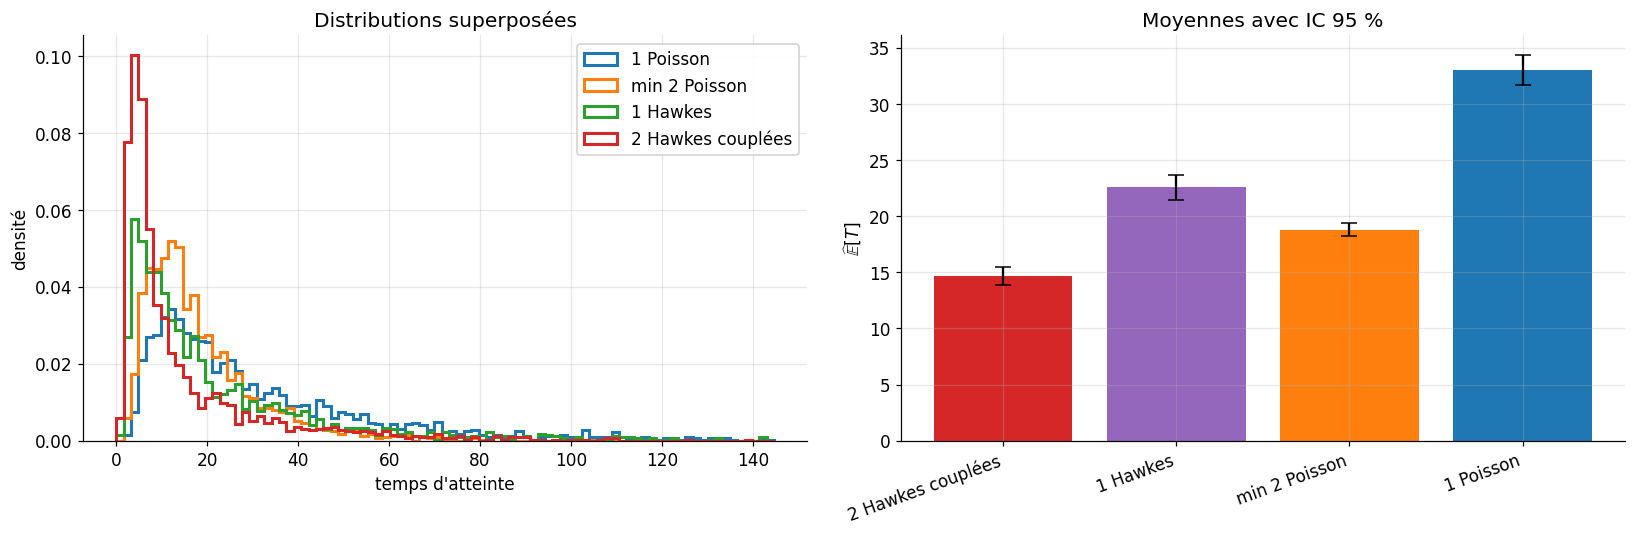

In [17]:
ordre_attendu = ["2 Hawkes couplées", "1 Hawkes", "min 2 Poisson", "1 Poisson"]

table_ord = table_comparaison.set_index("modèle").loc[ordre_attendu]
moyennes = table_ord["E[T]"].values
ordre_verifie = bool(np.all(np.diff(moyennes) > 0))

print(f"Ordre attendu vérifié ? {ordre_verifie}")
for nom, val in zip(ordre_attendu, moyennes):
    print(f"  {nom:20s} : {val:.4f}")

valeurs = np.concatenate(list(donnees.values()))
bins = np.linspace(0, np.quantile(valeurs, 0.995), 90)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for nom in ordre_attendu[::-1]:
    axes[0].hist(donnees[nom], bins=bins, density=True, histtype="step", linewidth=2, label=nom)
axes[0].set_xlabel("temps d'atteinte")
axes[0].set_ylabel("densité")
axes[0].set_title("Distributions superposées")
axes[0].legend()

err = np.vstack([
    moyennes - table_ord["IC 95% bas"].values,
    table_ord["IC 95% haut"].values - moyennes,
])
axes[1].bar(range(len(ordre_attendu)), moyennes, yerr=err, capsize=5, color=["tab:red", "tab:purple", "tab:orange", "tab:blue"])
axes[1].set_xticks(range(len(ordre_attendu)))
axes[1].set_xticklabels(ordre_attendu, rotation=20, ha="right")
axes[1].set_ylabel(r"$\widehat{\mathbb{E}}[T]$")
axes[1].set_title("Moyennes avec IC 95 %")

plt.tight_layout()
plt.show()


**Discussion.** Un ajout rend la file plus persistante : il
réduit temporairement le taux de retrait. Un retrait, au contraire, signale
une consommation en cours et augmente temporairement le taux de retrait. Le
modèle combine donc une inertie après les ajouts et une auto-excitation après
les retraits.

L'ordre attendu par l'énoncé doit être lu avec prudence : il dépend de la
convention de signes et du fait que les files sont arrêtées au bord zéro.
